In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#load datasets
train_raw = pd.read_csv('/content/drive/MyDrive/jjjj/Hotel-A-train.csv')
val_raw   = pd.read_csv('/content/drive/MyDrive/jjjj/Hotel-A-validation.csv')
test_raw  = pd.read_csv('/content/drive/MyDrive/jjjj/Hotel-A-test.csv')

print(f'Train shape   : {train_raw.shape}')
print(f'Validation    : {val_raw.shape}')
print(f'Test shape    : {test_raw.shape}')

Train shape   : (27499, 24)
Validation    : (2749, 24)
Test shape    : (4318, 23)


In [ ]:
# Loading data from local workspace

DATA_DIR = Path('/content/drive/MyDrive/jjjj/')
TRAIN_PATH = DATA_DIR / 'Hotel-A-train.csv'
VALIDATION_PATH = DATA_DIR / 'Hotel-A-validation.csv'
TEST_PATH = DATA_DIR / 'Hotel-A-test.csv'

train = pd.read_csv(TRAIN_PATH, encoding='utf-8-sig')
val = pd.read_csv(VALIDATION_PATH, encoding='utf-8-sig')
test = pd.read_csv(TEST_PATH, encoding='utf-8-sig')

print(f"Train shape:      {train.shape}")
print(f"Validation shape: {val.shape}")
print(f"Test shape:       {test.shape}")

Train shape:      (27499, 24)
Validation shape: (2749, 24)
Test shape:       (4318, 23)


In [ ]:
#summary statistics
print("NUMERICAL SUMMARY STATISTICS")
print("="*60)
num_cols = ['Age', 'Adults', 'Children', 'Babies', 'Discount_Rate', 'Room_Rate']
print(train[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).round(2))

NUMERICAL SUMMARY STATISTICS
            Age    Adults  Children    Babies  Discount_Rate  Room_Rate
count  27499.00  27499.00  27499.00  27499.00       27499.00   27499.00
mean      43.98      2.33      1.74      0.35          12.50     175.14
std       15.30      1.18      0.72      0.57          11.21      43.88
min       18.00      1.00      1.00      0.00           0.00     100.00
25%       31.00      2.00      1.00      0.00           5.00     137.00
50%       44.00      2.00      2.00      0.00          10.00     175.00
75%       57.00      3.00      2.00      1.00          20.00     214.00
max       70.00      5.00      3.00      2.00          40.00     250.00


In [ ]:
# SUMMARY STATISTICS — CATEGORICAL

print("CATEGORICAL SUMMARY STATISTICS")
print("="*60)
cat_cols = [
    'Gender', 'Ethnicity', 'Educational_Level', 'Income',
    'Country_region', 'Hotel_Type', 'Meal_Type',
    'Visted_Previously', 'Previous_Cancellations',
    'Deposit_type', 'Booking_channel', 'Required_Car_Parking',
    'Use_Promotion', 'Reservation_Status'
]
for col in cat_cols:
    vc = train[col].value_counts()
    print(f"\n{col} ({train[col].nunique()} unique values):")
    for val_name, count in vc.items():
        print(f"  {val_name:<25} {count:>6}  ({count/len(train)*100:.1f}%)")


CATEGORICAL SUMMARY STATISTICS

Gender (2 unique values):
  F                          13799  (50.2%)
  M                          13700  (49.8%)

Ethnicity (4 unique values):
  African American            6965  (25.3%)
  caucasian                   6890  (25.1%)
  Asian American              6838  (24.9%)
  Latino                      6806  (24.7%)

Educational_Level (4 unique values):
  College                    11052  (40.2%)
  High-School                 5522  (20.1%)
  Mid-School                  5481  (19.9%)
  Grad                        5444  (19.8%)

Income (4 unique values):
  50K -- 100K                 7936  (28.9%)
  25K --50K                   7870  (28.6%)
  <25K                        7739  (28.1%)
  >100K                       3954  (14.4%)

Country_region (4 unique values):
  South                      10917  (39.7%)
  North                       5670  (20.6%)
  East                        5460  (19.9%)
  West                        5452  (19.8%)

Hotel_Type (3 uniqu

In [ ]:
# 4. DATA QUALITY ISSUES IDENTIFIED

print("DATA QUALITY ISSUES")
print("=" * 60)

# Issue 1: Duplicate label due to case mismatch
status_vals = train['Reservation_Status'].unique()
print(f"\n[Issue 1] Reservation_Status unique values: {list(status_vals)}")
print("  -> 'Check-Out' and 'Check-out' represent the same class.")
print("  -> Decision: standardise all to 'Check-Out'.")

# Issue 2: Ethnicity capitalisation inconsistency
print("\n[Issue 2] Ethnicity contains 'caucasian' (lowercase) and title-case labels.")
print("  -> Decision: rename 'caucasian' to 'Caucasian'.")

# Issue 3: Missing values
print("\n[Issue 3] Missing values per column:")
missing = train.isnull().sum()
print(missing[missing > 0] if missing.any() else "  -> No missing values found.")

# Issue 4: Negative lead times (booking date after check-in date)
train_tmp = train.copy()
train_tmp['checkin'] = pd.to_datetime(train_tmp['Expected_checkin'])
train_tmp['booking'] = pd.to_datetime(train_tmp['Booking_date'])
train_tmp['lead_time'] = (train_tmp['checkin'] - train_tmp['booking']).dt.days
neg_leads = int((train_tmp['lead_time'] < 0).sum())
print(f"\n[Issue 4] Negative lead times: {neg_leads} rows ({neg_leads / len(train) * 100:.2f}%)")
print("  -> Booking date recorded after check-in date, likely data entry error.")
print("  -> Decision: remove these rows during cleaning.")

# Issue 5: Children column has no zero values
print(f"\n[Issue 5] Children value counts: {train['Children'].value_counts().sort_index().to_dict()}")
print("  -> No bookings with 0 children. Likely collection bias or pre-filtering.")
print("  -> Decision: keep as-is and document as a limitation.")

# Issue 6: Very long lead-time outliers
q1, q3 = train_tmp['lead_time'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

# Cap
train_tmp['lead_time'] = train_tmp['lead_time'].clip(upper=upper_fence)

#4 Bin
train_tmp['lead_time_bucket'] = pd.cut(
    train_tmp['lead_time'],
    bins=[-1, 3, 14, 60, 180, 365, np.inf],
    labels=[0,1,2,3,4,5]
).astype(float).fillna(0).astype(int)

DATA QUALITY ISSUES

[Issue 1] Reservation_Status unique values: ['Check-Out', 'Canceled', 'No-Show', 'Check-out']
  -> 'Check-Out' and 'Check-out' represent the same class.
  -> Decision: standardise all to 'Check-Out'.

[Issue 2] Ethnicity contains 'caucasian' (lowercase) and title-case labels.
  -> Decision: rename 'caucasian' to 'Caucasian'.

[Issue 3] Missing values per column:
  -> No missing values found.

[Issue 4] Negative lead times: 506 rows (1.84%)
  -> Booking date recorded after check-in date, likely data entry error.
  -> Decision: remove these rows during cleaning.

[Issue 5] Children value counts: {1: 11590, 2: 11362, 3: 4547}
  -> No bookings with 0 children. Likely collection bias or pre-filtering.
  -> Decision: keep as-is and document as a limitation.


In [ ]:
# 5. Data cleaning
def clean_dataset(df, dataset_name="dataset"):
    """Apply cleaning and feature-engineering steps to a dataset."""
    df = df.copy()

    # Standardise Reservation_Status labels
    if 'Reservation_Status' in df.columns:
        df['Reservation_Status'] = df['Reservation_Status'].replace({'Check-out': 'Check-Out'})

    # Standardise Ethnicity capitalisation
    if 'Ethnicity' in df.columns:
        df['Ethnicity'] = df['Ethnicity'].replace({'caucasian': 'Caucasian'})

    # Date parsing
    df['checkin'] = pd.to_datetime(df['Expected_checkin'], errors='coerce')
    df['checkout'] = pd.to_datetime(df['Expected_checkout'], errors='coerce')
    df['booking'] = pd.to_datetime(df['Booking_date'], errors='coerce')

    # Date-derived features
    df['lead_time'] = (df['checkin'] - df['booking']).dt.days
    df['stay_nights'] = (df['checkout'] - df['checkin']).dt.days
    df['checkin_month'] = df['checkin'].dt.month
    df['checkin_month_name'] = df['checkin'].dt.strftime('%b')
    df['checkin_dayofweek'] = df['checkin'].dt.dayofweek  # 0=Mon, 6=Sun
    df['booking_month'] = df['booking'].dt.month

    #  remove impossible negative lead-time rows
    neg_mask = df['lead_time'] < 0
    removed_neg = int(neg_mask.sum())
    if removed_neg > 0:
        df = df.loc[~neg_mask].copy()

    # remove non-positive stays if any exist
    bad_stay_mask = df['stay_nights'] <= 0
    removed_stay = int(bad_stay_mask.sum())
    if removed_stay > 0:
        df = df.loc[~bad_stay_mask].copy()

    # Target variable for labelled datasets
    if 'Reservation_Status' in df.columns:
        df['is_cancelled'] = df['Reservation_Status'].isin(['Canceled', 'No-Show']).astype(int)

    print(f"\n{dataset_name} cleaned: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"  Removed negative lead_time rows: {removed_neg}")
    print(f"  Removed non-positive stay_nights rows: {removed_stay}")
    return df

train_clean = clean_dataset(train, "Train")
val_clean = clean_dataset(val, "Validation")
test_clean = clean_dataset(test, "Test")


Train cleaned: 26993 rows, 34 columns
  Removed negative lead_time rows: 506
  Removed non-positive stay_nights rows: 0

Validation cleaned: 2733 rows, 34 columns
  Removed negative lead_time rows: 16
  Removed non-positive stay_nights rows: 0

Test cleaned: 4291 rows, 32 columns
  Removed negative lead_time rows: 27
  Removed non-positive stay_nights rows: 0


In [ ]:
# 6. Save cleaned datasets + cleaning review summary
train_clean.to_csv('Hotel-A-train-clean.csv', index=False)
val_clean.to_csv('Hotel-A-validation-clean.csv', index=False)
test_clean.to_csv('Hotel-A-test-clean.csv', index=False)

print("\nCleaned datasets saved:")
print("  - Hotel-A-train-clean.csv")
print("  - Hotel-A-validation-clean.csv")
print("  - Hotel-A-test-clean.csv")


print("\nRow counts after cleaning:")
print(f"  Train      : {len(train):,} -> {len(train_clean):,}")
print(f"  Validation : {len(val):,} -> {len(val_clean):,}")
print(f"  Test       : {len(test):,} -> {len(test_clean):,}")


Cleaned datasets saved:
  - Hotel-A-train-clean.csv
  - Hotel-A-validation-clean.csv
  - Hotel-A-test-clean.csv

Row counts after cleaning:
  Train      : 27,499 -> 26,993
  Validation : 2,749 -> 2,733
  Test       : 4,318 -> 4,291


EDA

In [ ]:
# Load the cleaned training file saved during the cleaning step
df = pd.read_csv('Hotel-A-train-clean.csv')

# Constants shared by all chart cells
BG = '#f8f8f6'
PALETTE = {'Check-Out': '#1D9E75', 'Canceled': '#D85A30', 'No-Show': '#7F77DD'}
MONTH_ORDER = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
STATUS_ORDER = ['Check-Out', 'Canceled', 'No-Show']

def status_mix_table(data, group_col, order=None):
    mix = pd.crosstab(data[group_col], data['Reservation_Status'], normalize='index')
    mix = mix.reindex(columns=STATUS_ORDER, fill_value=0).mul(100)
    if order is not None:
        mix = mix.reindex(order)
    return mix.fillna(0)

def plot_grouped_status_bars(ax, mix, title, ylabel, xticklabels=None, ylim=None):
    x = np.arange(len(mix.index))
    width = 0.24

    for i, status in enumerate(STATUS_ORDER):
        vals = mix[status].values
        bars = ax.bar(
            x + (i - 1) * width,
            vals,
            width=width,
            label=status,
            color=PALETTE[status],
            edgecolor='white',
            linewidth=1.2,
        )
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.35,
                    f'{v:.1f}%',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                    fontweight='bold',
                    color='#2C2C2A',
                )

    ax.set_xticks(x)
    if xticklabels is None:
        ax.set_xticklabels(mix.index)
    else:
        ax.set_xticklabels(xticklabels)

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_facecolor(BG)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=9, frameon=False)

# Confirm we are using the cleaned file
status_counts = df['Reservation_Status'].value_counts().reindex(STATUS_ORDER, fill_value=0)

print('Dataset: Hotel-A-train-clean.csv')
print(f'Rows: {len(df):,}  |  Columns: {len(df.columns)}')
print(f"Reservation_Status values : {df['Reservation_Status'].unique().tolist()}")
print(f"Ethnicity values          : {df['Ethnicity'].unique().tolist()}")
print('Class distribution:')
for status in STATUS_ORDER:
    c = int(status_counts[status])
    print(f'  {status:<9}: {c:>6,} ({c / len(df) * 100:>5.1f}%)')

agg_cancel = int(status_counts['Canceled'] + status_counts['No-Show'])
print(f'Canceled + No-Show        : {agg_cancel:,} ({agg_cancel / len(df) * 100:.1f}%)')

Dataset: Hotel-A-train-clean.csv
Rows: 26,993  |  Columns: 34
Reservation_Status values : ['Check-Out', 'Canceled', 'No-Show']
Ethnicity values          : ['Latino', 'Caucasian', 'African American', 'Asian American']
Class distribution:
  Check-Out: 20,777 ( 77.0%)
  Canceled :  4,108 ( 15.2%)
  No-Show  :  2,108 (  7.8%)
Canceled + No-Show        : 6,216 (23.0%)


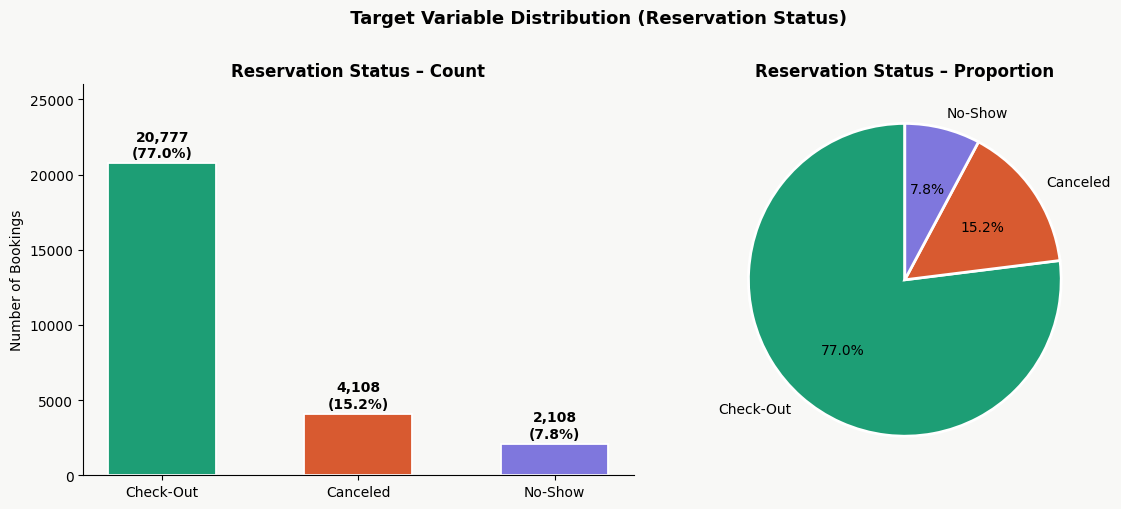


Class imbalance ratio (Check-Out : Canceled : No-Show):
  9.9 : 1.9 : 1.0


In [ ]:
# Target Variable Distribution

# Load the cleaned training file
df = pd.read_csv('Hotel-A-train-clean.csv')

# Constants shared by all chart cells
BG = '#f8f8f6'
PALETTE = {'Check-Out': '#1D9E75', 'Canceled': '#D85A30', 'No-Show': '#7F77DD'}
STATUS_ORDER = ['Check-Out', 'Canceled', 'No-Show']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG)

# Bar chart
counts = df['Reservation_Status'].value_counts().reindex(STATUS_ORDER)
colors = [PALETTE[s] for s in STATUS_ORDER]
bars   = ax1.bar(STATUS_ORDER, counts.values, color=colors, edgecolor='white', linewidth=1.3, width=0.55)
for bar, v in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{v:,}\n({v/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Reservation Status – Count', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of Bookings')
ax1.set_ylim(0, 26000)
ax1.set_facecolor(BG)
ax1.spines[['top','right']].set_visible(False)

# Pie chart
ax2.pie(counts.values, labels=STATUS_ORDER, colors=colors, autopct='%1.1f%%',
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
        textprops={'fontsize': 10})
ax2.set_title('Reservation Status – Proportion', fontweight='bold', fontsize=12)

fig.suptitle(' Target Variable Distribution (Reservation Status)', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nClass imbalance ratio (Check-Out : Canceled : No-Show):')
print(f"  {counts['Check-Out']/counts['No-Show']:.1f} : {counts['Canceled']/counts['No-Show']:.1f} : 1.0")

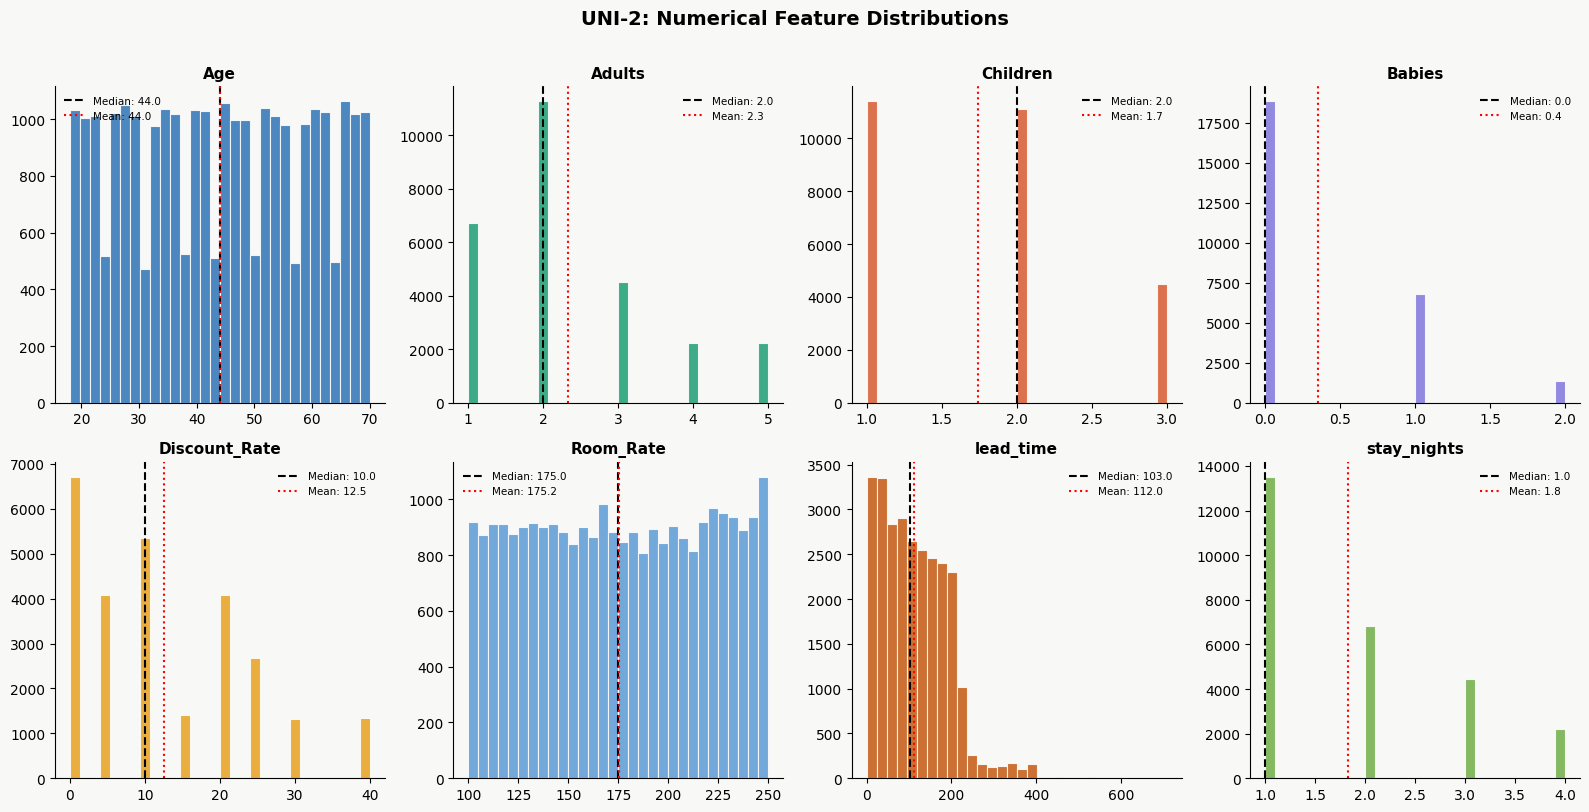


Summary statistics for numerical features:
            Age    Adults  Children    Babies  Discount_Rate  Room_Rate  \
count  26993.00  26993.00  26993.00  26993.00       26993.00   26993.00   
mean      44.01      2.33      1.74      0.35          12.50     175.19   
std       15.31      1.18      0.72      0.57          11.21      43.87   
min       18.00      1.00      1.00      0.00           0.00     100.00   
25%       31.00      2.00      1.00      0.00           5.00     137.00   
50%       44.00      2.00      2.00      0.00          10.00     175.00   
75%       57.00      3.00      2.00      1.00          20.00     214.00   
max       70.00      5.00      3.00      2.00          40.00     250.00   

       lead_time  stay_nights  
count   26993.00     26993.00  
mean      112.00         1.83  
std        77.25         0.98  
min         0.00         1.00  
25%        48.00         1.00  
50%       103.00         1.00  
75%       167.00         2.00  
max       708.00        

In [ ]:
# Numerical Feature Distributions
# Histograms for all 8 numerical features , this reveals skewness, ranges and outliers.

NUM_COLS = ['Age', 'Adults', 'Children', 'Babies', 'Discount_Rate', 'Room_Rate', 'lead_time', 'stay_nights']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

colors_num = ['#2E75B6','#1D9E75','#D85A30','#7F77DD','#E8A020','#5B9BD5','#C55A11','#70AD47']

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    ax.set_facecolor(BG)
    data = df[col].dropna()
    ax.hist(data, bins=30, color=colors_num[i], edgecolor='white', linewidth=0.8, alpha=0.85)
    # Annotate with median and mean
    med, mn = data.median(), data.mean()
    ax.axvline(med, color='black',  linestyle='--', linewidth=1.5, label=f'Median: {med:.1f}')
    ax.axvline(mn,  color='red',    linestyle=':',  linewidth=1.5, label=f'Mean: {mn:.1f}')
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.legend(fontsize=7.5, frameon=False)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('UNI-2: Numerical Feature Distributions', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nSummary statistics for numerical features:')
print(df[NUM_COLS].describe(percentiles=[.25,.5,.75]).round(2))

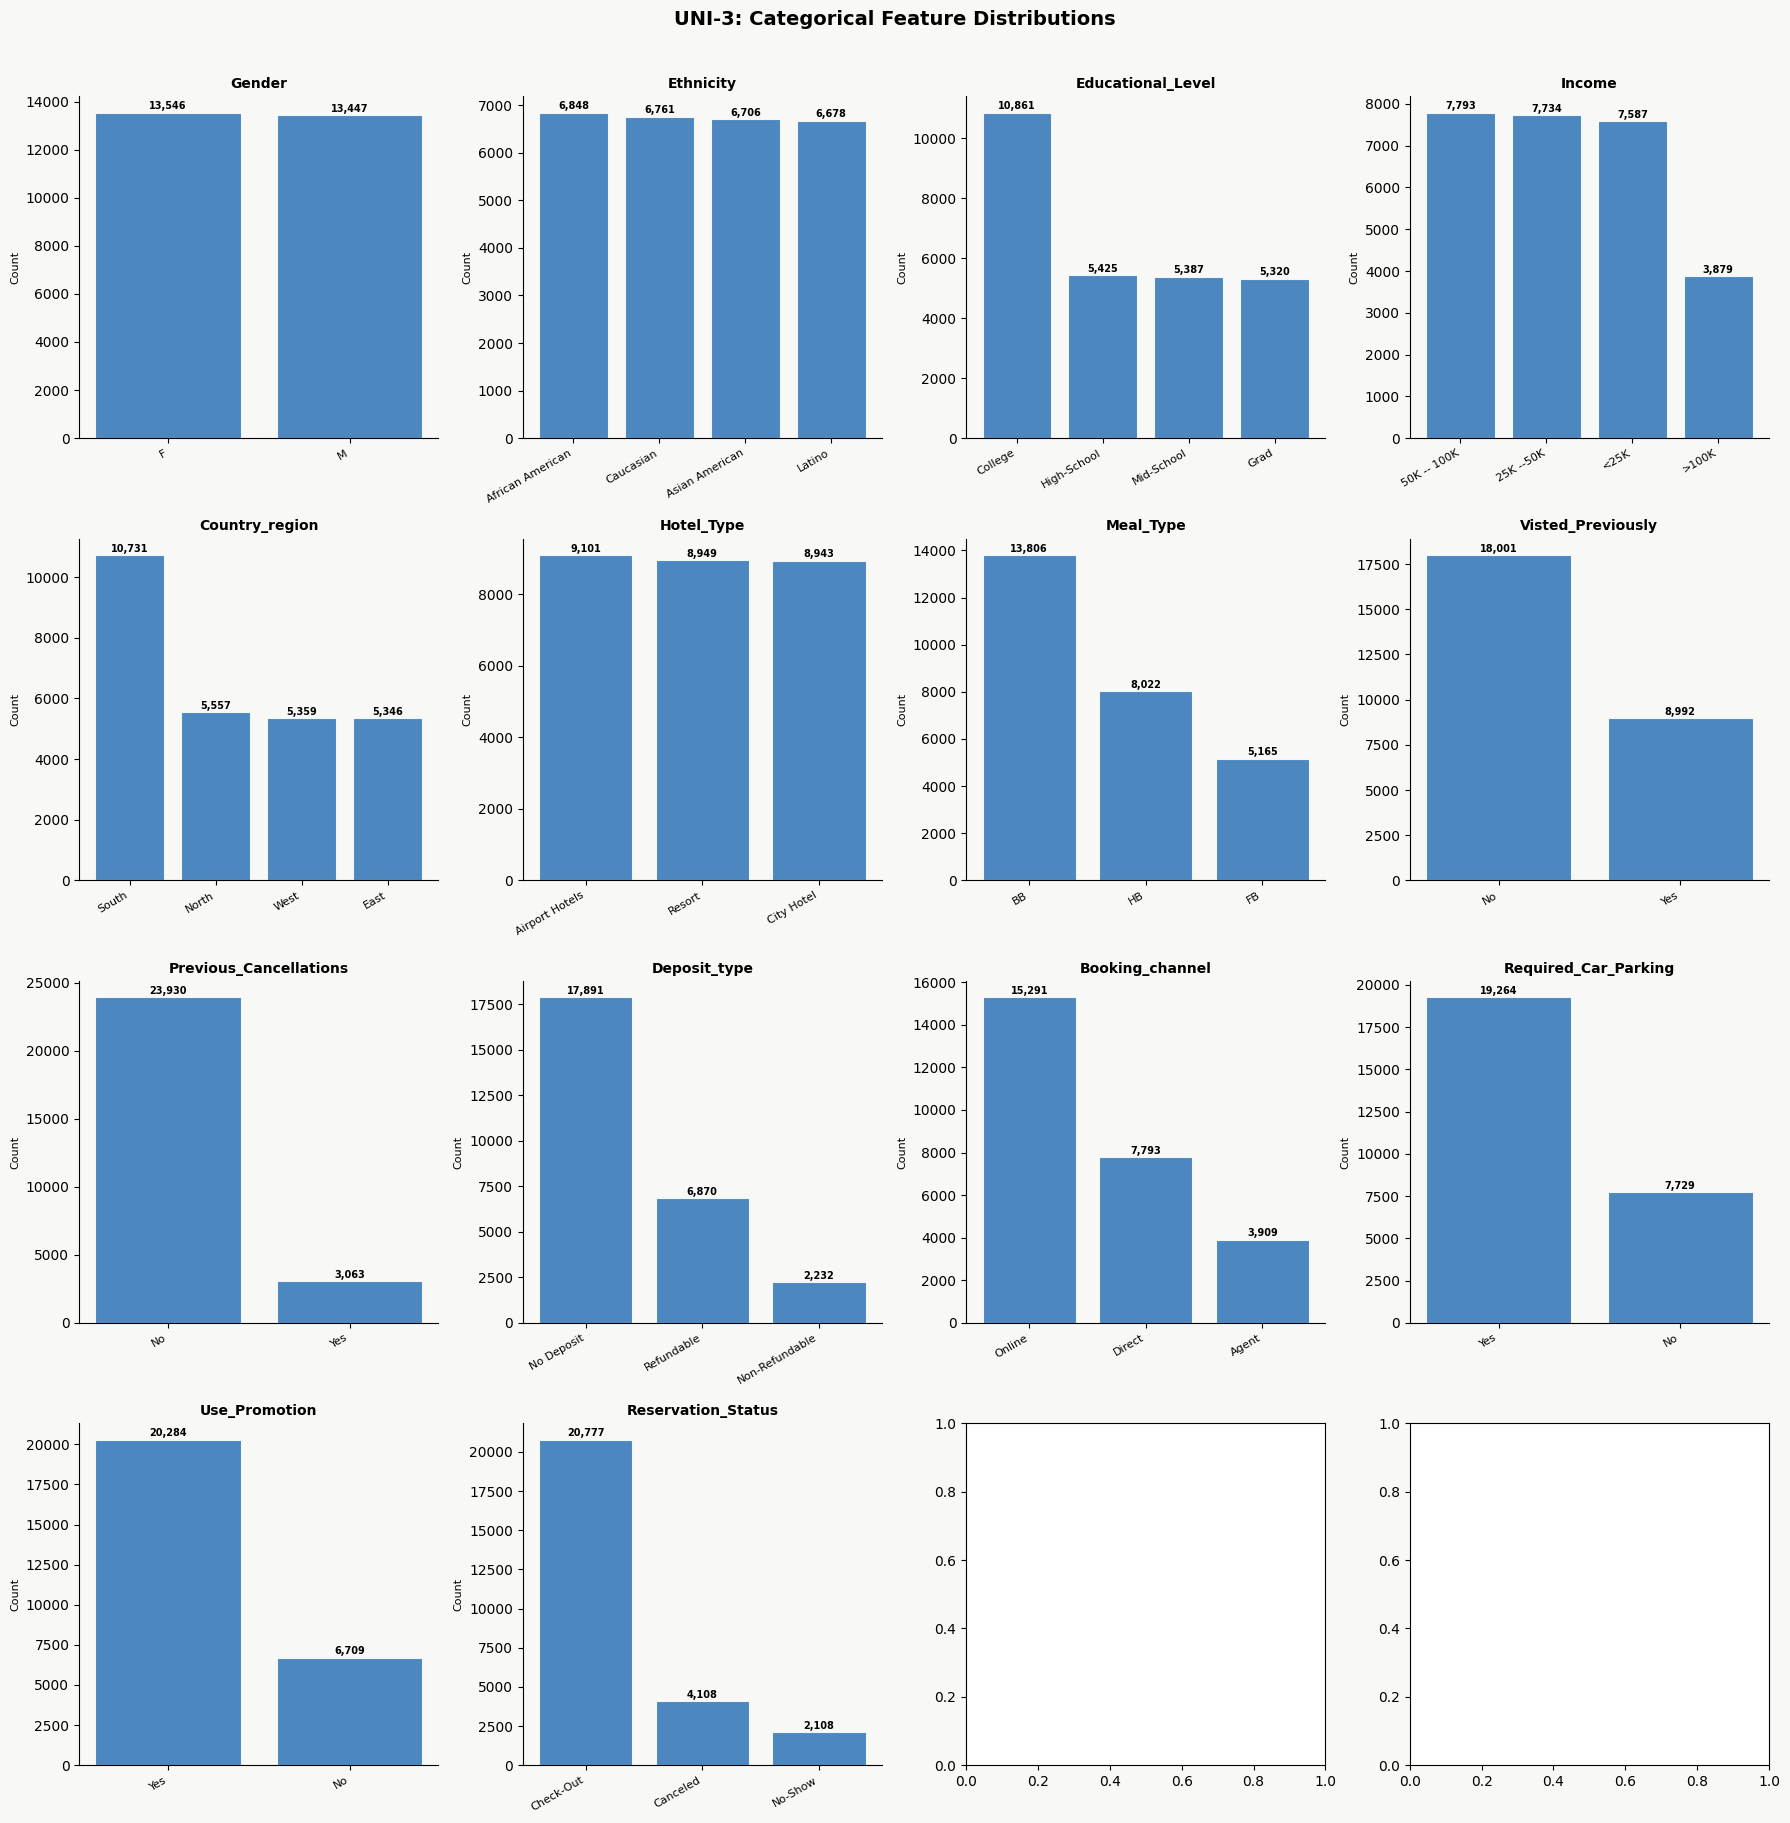

In [ ]:
# Categorical Feature Distributions
# Bar charts for all categorical features

CAT_COLS = [
    'Gender', 'Ethnicity', 'Educational_Level', 'Income',
    'Country_region', 'Hotel_Type', 'Meal_Type',
    'Visted_Previously', 'Previous_Cancellations',
    'Deposit_type', 'Booking_channel', 'Required_Car_Parking',
    'Use_Promotion', 'Reservation_Status'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 18))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    ax = axes[i]
    ax.set_facecolor(BG)
    vc = df[col].value_counts()
    ax.bar(range(len(vc)), vc.values, color='#2E75B6', edgecolor='white', linewidth=0.8, alpha=0.85)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel('Count', fontsize=8)
    # Add count labels
    for j, v in enumerate(vc.values):
        ax.text(j, v + vc.max()*0.01, f'{v:,}', ha='center', fontsize=7, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('UNI-3: Categorical Feature Distributions', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

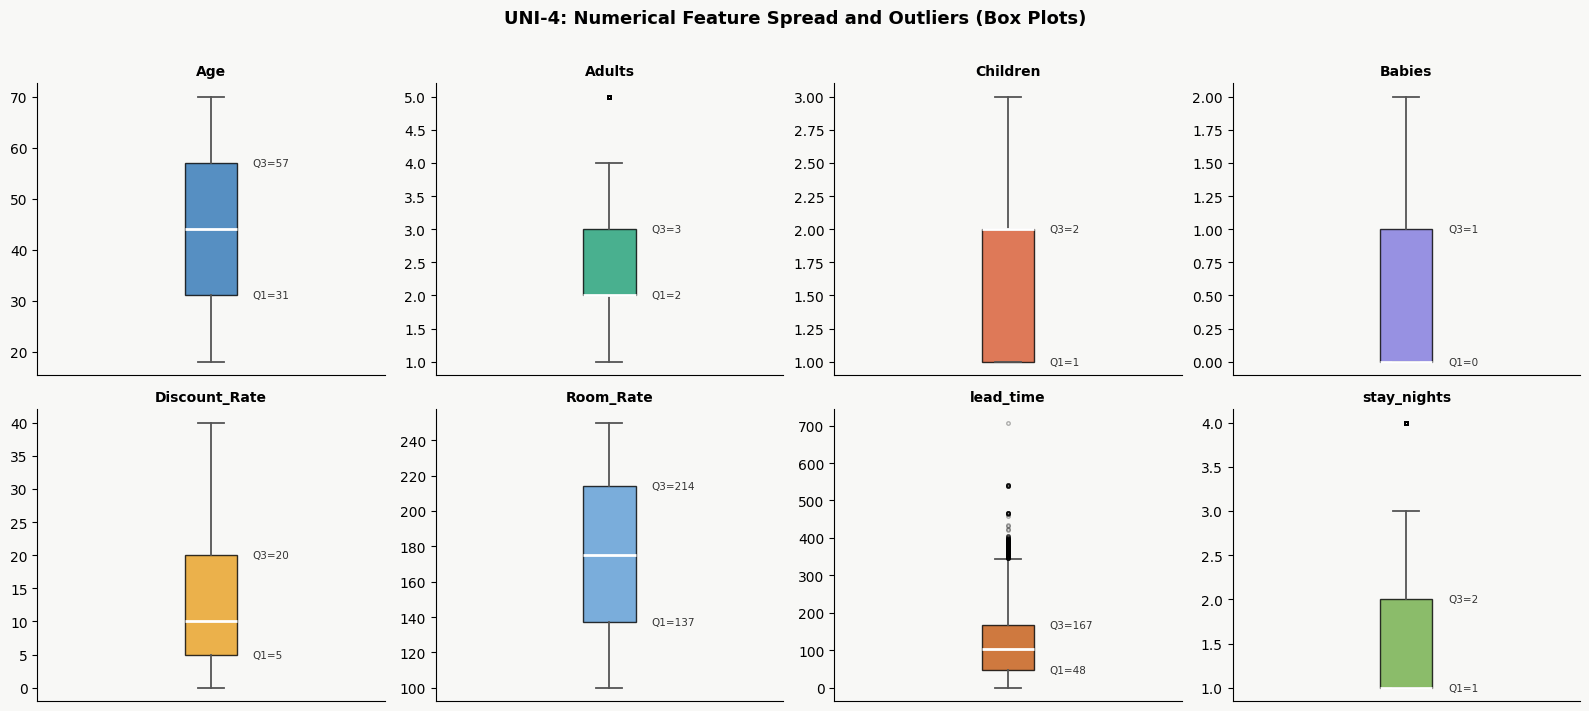

In [ ]:
# Spread and Outliers for Numerical Features
# Box plots show quartiles, IQR and outlier extent for each numerical variable.

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    ax.set_facecolor(BG)
    bp = ax.boxplot(df[col].dropna(), patch_artist=True, vert=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=1.3, color='#555'),
                    capprops=dict(linewidth=1.3, color='#555'),
                    flierprops=dict(marker='o', markersize=2.5, alpha=0.3, color='#888'))
    bp['boxes'][0].set_facecolor(colors_num[i])
    bp['boxes'][0].set_alpha(0.8)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xticks([])
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    ax.text(1.12, q3, f'Q3={q3:.0f}', va='center', fontsize=7.5, color='#333')
    ax.text(1.12, q1, f'Q1={q1:.0f}', va='center', fontsize=7.5, color='#333')
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('UNI-4: Numerical Feature Spread and Outliers (Box Plots)', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

BIVARIATE ANALYSIS

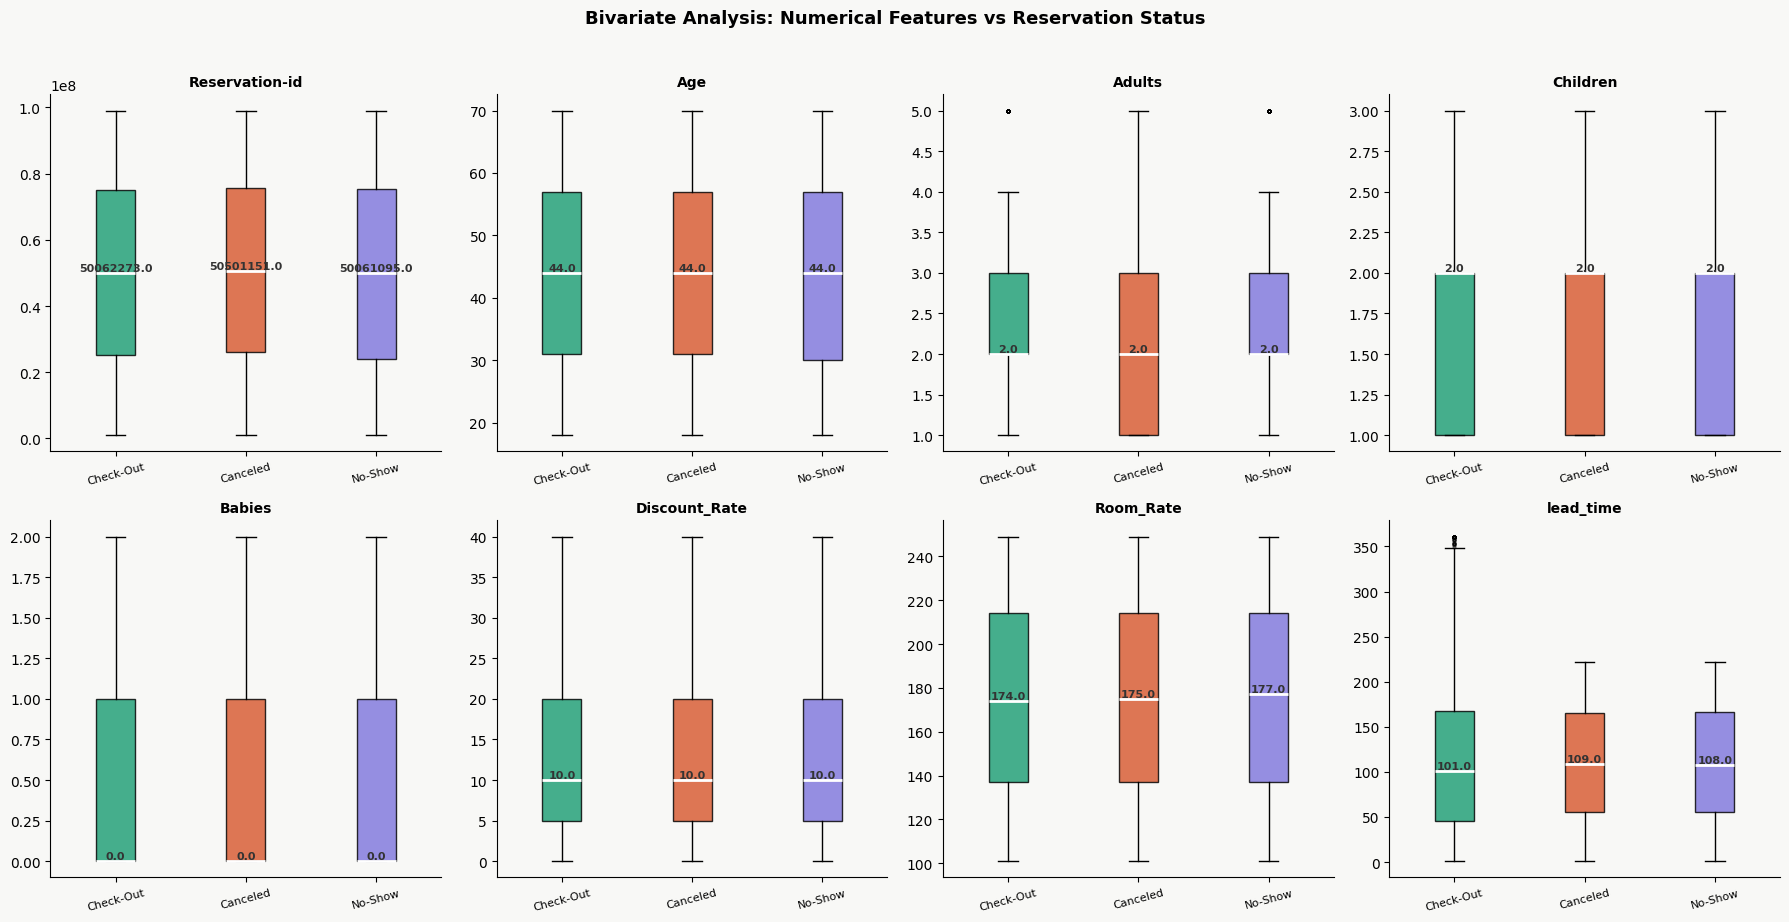

In [ ]:

#visualisation of numerical features by reservation status
#SETTINGS
BG = '#f8f8f6'

STATUS_ORDER = ['Check-Out', 'Canceled', 'No-Show']

PALETTE = {
    'Check-Out': '#1D9E75',
    'Canceled': '#D85A30',
    'No-Show': '#7F77DD'
}

# Select numerical columns (exclude target if included)
NUM_COLS = df.select_dtypes(include=[np.number]).columns.tolist()
if 'is_cancelled' in NUM_COLS:
    NUM_COLS.remove('is_cancelled')

#loop through numerical features and create boxplots by Reservation_Status
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor(BG)
axes = axes.flatten()
for i, col in enumerate(NUM_COLS[:8]):
    ax = axes[i]
    ax.set_facecolor(BG)

    # Handle outliers (clip to 1st–99th percentile)
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    data_by_class = []
    medians = []

    for status in STATUS_ORDER:
        subset = df[df['Reservation_Status'] == status][col]

        # Clip extreme values
        subset = subset.clip(lower, upper).dropna()

        # Handle empty groups safely
        if subset.empty:
            subset = [0]

        data_by_class.append(subset)
        medians.append(np.median(subset))

# Create boxplot
    bp = ax.boxplot(
        data_by_class,
        patch_artist=True,
        tick_labels=STATUS_ORDER,
        medianprops=dict(color='white', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )

# Apply colors
    for patch, status in zip(bp['boxes'], STATUS_ORDER):
        patch.set_facecolor(PALETTE[status])
        patch.set_alpha(0.82)

    # Titles & formatting
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xticklabels(STATUS_ORDER, rotation=15, fontsize=8)
    ax.spines[['top','right']].set_visible(False)

    # Add median labels
    for j, med in enumerate(medians):
        ax.text(j+1, med, f'{med:.1f}',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='#333')

# Remove empty subplots if fewer than 8 features
for j in range(len(NUM_COLS[:8]), len(axes)):
    fig.delaxes(axes[j])

# Title
fig.suptitle(
    'Bivariate Analysis: Numerical Features vs Reservation Status',
    fontweight='bold',
    fontsize=13,
    y=1.02
)

plt.tight_layout()
plt.show()

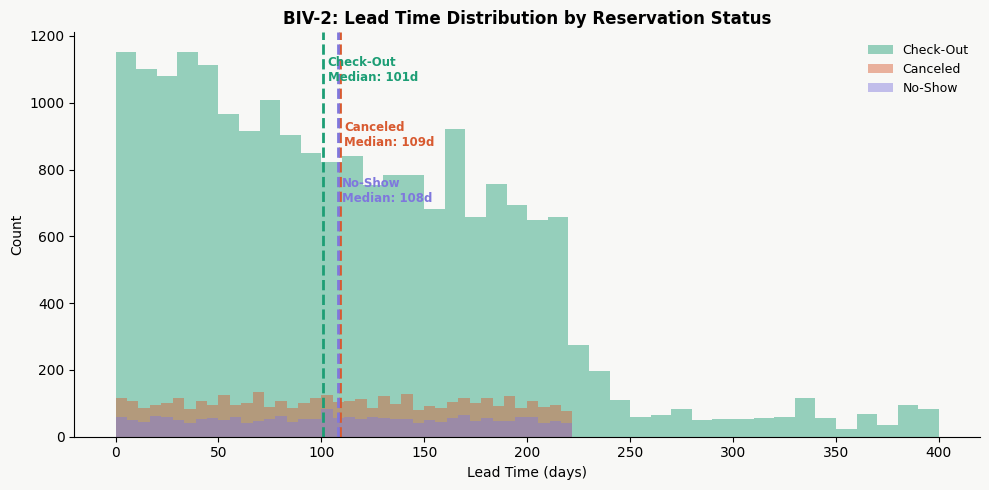

Lead time summary by class:
                     mean  median   std
Reservation_Status                     
Canceled            109.7   109.0  63.2
Check-Out           112.7   101.0  81.0
No-Show             110.0   108.0  63.2


In [ ]:
#Lead Time Distribution by Reservation Status

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)

median_map = {}
for status in STATUS_ORDER:
    s = df[df['Reservation_Status'] == status]['lead_time'].clip(0, 400)
    ax.hist(s, bins=40, alpha=0.45, color=PALETTE[status], label=status, edgecolor='none')
    median_map[status] = s.median()
    ax.axvline(median_map[status], color=PALETTE[status], linestyle='--', linewidth=2)

for status, med in median_map.items():
    ax.text(med + 2, ax.get_ylim()[1] * 0.88 if status=='Check-Out' else
            ax.get_ylim()[1] * 0.72 if status=='Canceled' else
            ax.get_ylim()[1] * 0.58,
            f'{status}\nMedian: {med:.0f}d',
            color=PALETTE[status], fontsize=8.5, fontweight='bold')

ax.set_title('BIV-2: Lead Time Distribution by Reservation Status', fontweight='bold', fontsize=12)
ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('Count')
ax.legend(fontsize=9, frameon=False)
ax.set_facecolor(BG)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Lead time summary by class:')
print(df.groupby('Reservation_Status')['lead_time'].agg(['mean','median','std']).round(1))

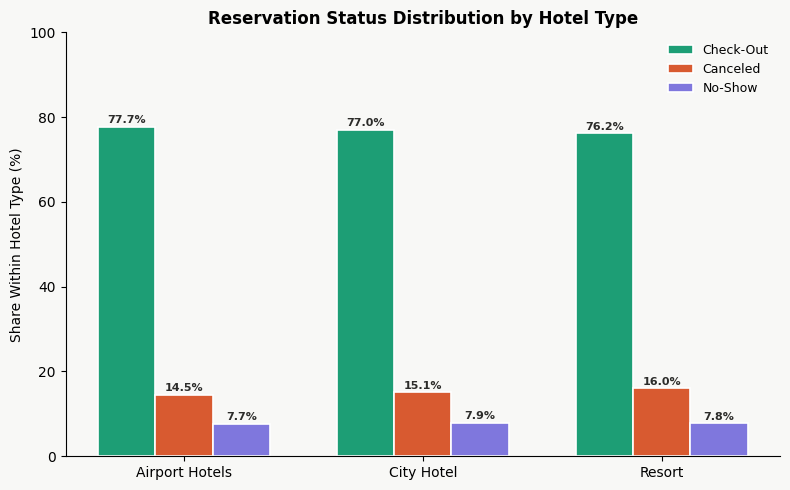

In [ ]:
#RESERVATION STATUS MIX BY HOTEL TYPE
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)

mix = status_mix_table(df, 'Hotel_Type')
plot_grouped_status_bars(
    ax=ax,
    mix=mix,
    title='Reservation Status Distribution by Hotel Type',
    ylabel='Share Within Hotel Type (%)',
    ylim=(0, 100),
)

plt.tight_layout()
plt.show()

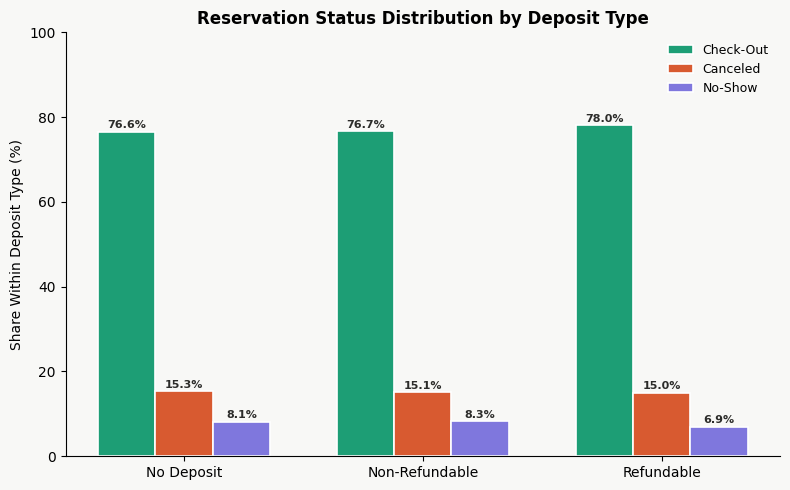

In [ ]:
#RESERVATION STATUS MIX BY DEPOSIT TYPE
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)

mix = status_mix_table(df, 'Deposit_type')
plot_grouped_status_bars(
    ax=ax,
    mix=mix,
    title='Reservation Status Distribution by Deposit Type',
    ylabel='Share Within Deposit Type (%)',
    ylim=(0, 100),
)

plt.tight_layout()
plt.show()

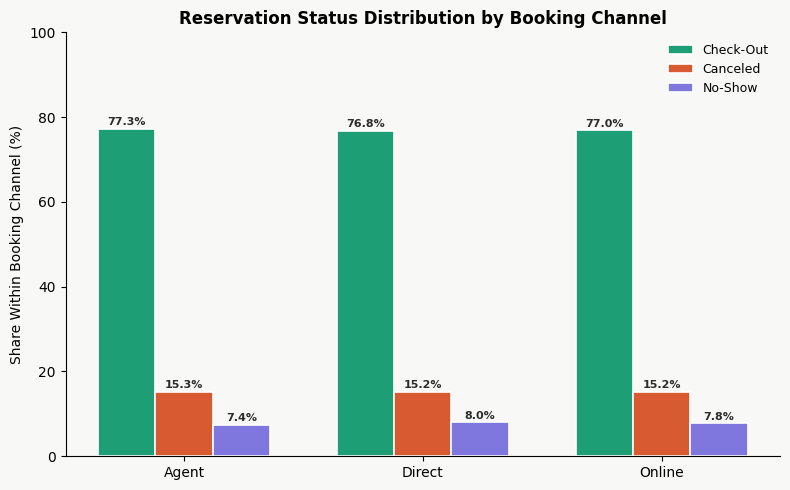

In [ ]:
#RESERVATION STATUS MIX BY BOOKING CHANNEL
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)

mix = status_mix_table(df, 'Booking_channel')
plot_grouped_status_bars(
    ax=ax,
    mix=mix,
    title='Reservation Status Distribution by Booking Channel',
    ylabel='Share Within Booking Channel (%)',
    ylim=(0, 100),
)

plt.tight_layout()
plt.show()

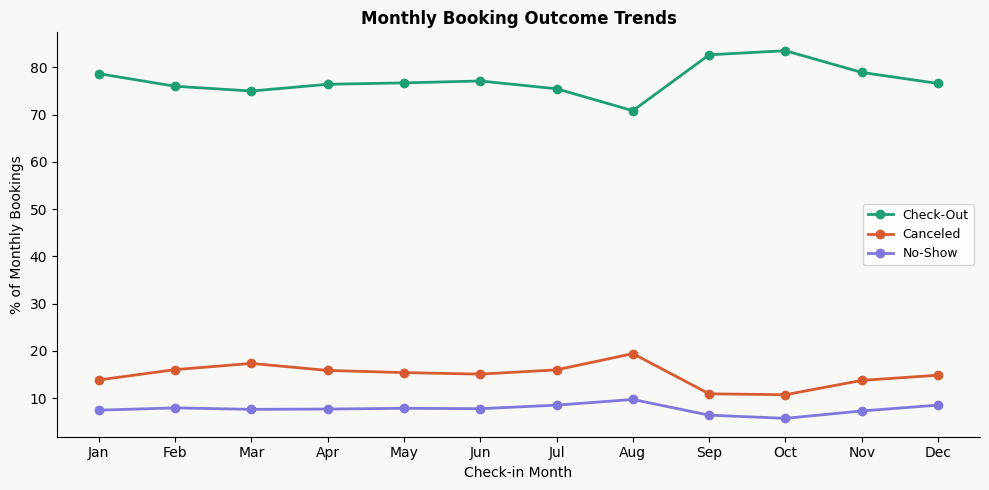

In [ ]:
#MONTHLY BOOKING OUTCOME TRENDS
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)

monthly        = df.groupby(
    ['checkin_month', 'checkin_month_name', 'Reservation_Status']
).size().reset_index(name='count')
totals         = monthly.groupby('checkin_month')['count'].transform('sum')
monthly['pct'] = monthly['count'] / totals * 100
monthly        = monthly.sort_values('checkin_month')

for status in ['Check-Out', 'Canceled', 'No-Show']:
    sub = monthly[monthly['Reservation_Status'] == status]
    ml  = [MONTH_ORDER[m - 1] for m in sub['checkin_month']]
    ax.plot(ml, sub['pct'], marker='o', color=PALETTE[status],
            label=status, linewidth=2, markersize=6)

ax.set_title('Monthly Booking Outcome Trends', fontweight='bold', fontsize=12)
ax.set_xlabel('Check-in Month')
ax.set_ylabel('% of Monthly Bookings')
ax.legend(fontsize=9)
ax.set_facecolor(BG)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

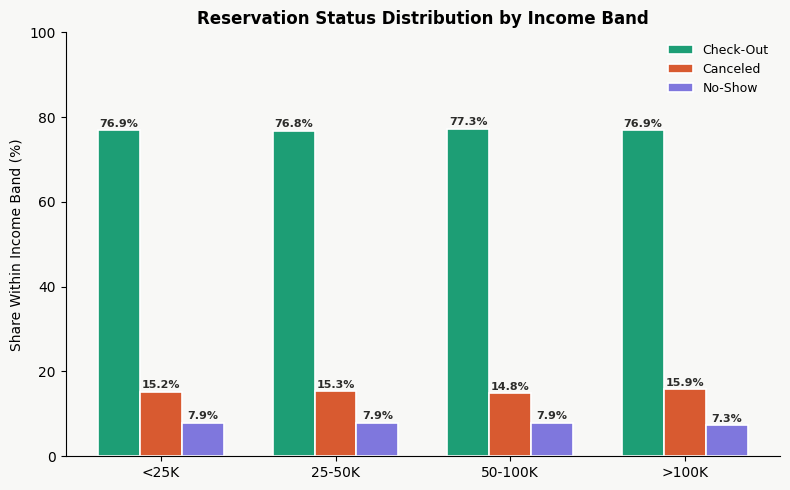

In [ ]:
#RESERVATION STATUS MIX BY INCOME BAND
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)

inc_order = ['<25K', '25K --50K', '50K -- 100K', '>100K']
mix = status_mix_table(df, 'Income', order=inc_order)
plot_grouped_status_bars(
    ax=ax,
    mix=mix,
    title='Reservation Status Distribution by Income Band',
    ylabel='Share Within Income Band (%)',
    xticklabels=['<25K', '25-50K', '50-100K', '>100K'],
    ylim=(0, 100),
)

plt.tight_layout()
plt.show()

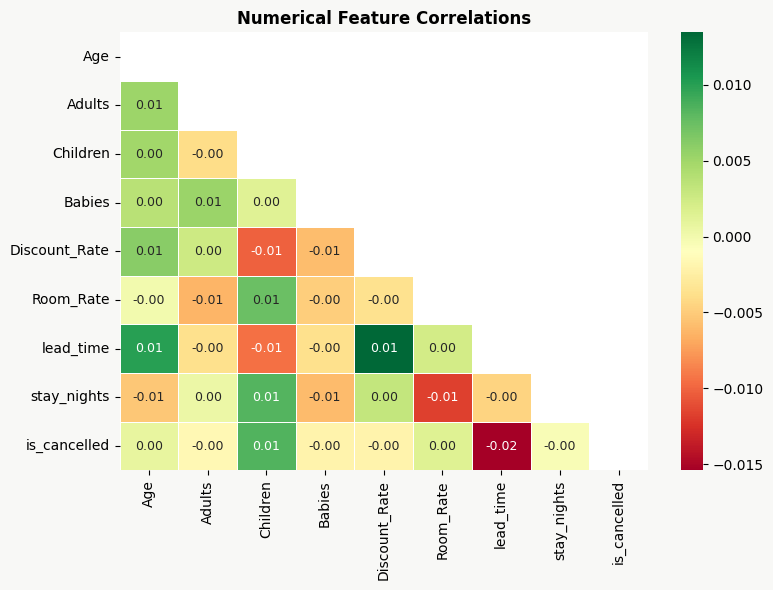

In [ ]:
#NUMERICAL FEATURE CORRELATIONS
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG)

num_feats = ['Age', 'Adults', 'Children', 'Babies', 'Discount_Rate',
             'Room_Rate', 'lead_time', 'stay_nights', 'is_cancelled']
corr = df[num_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, ax=ax, mask=mask,
    annot=True, fmt='.2f', cmap='RdYlGn',
    linewidths=0.5, annot_kws={'size': 9}, cbar=True
)

ax.set_title('Numerical Feature Correlations', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


Multivariate analysis

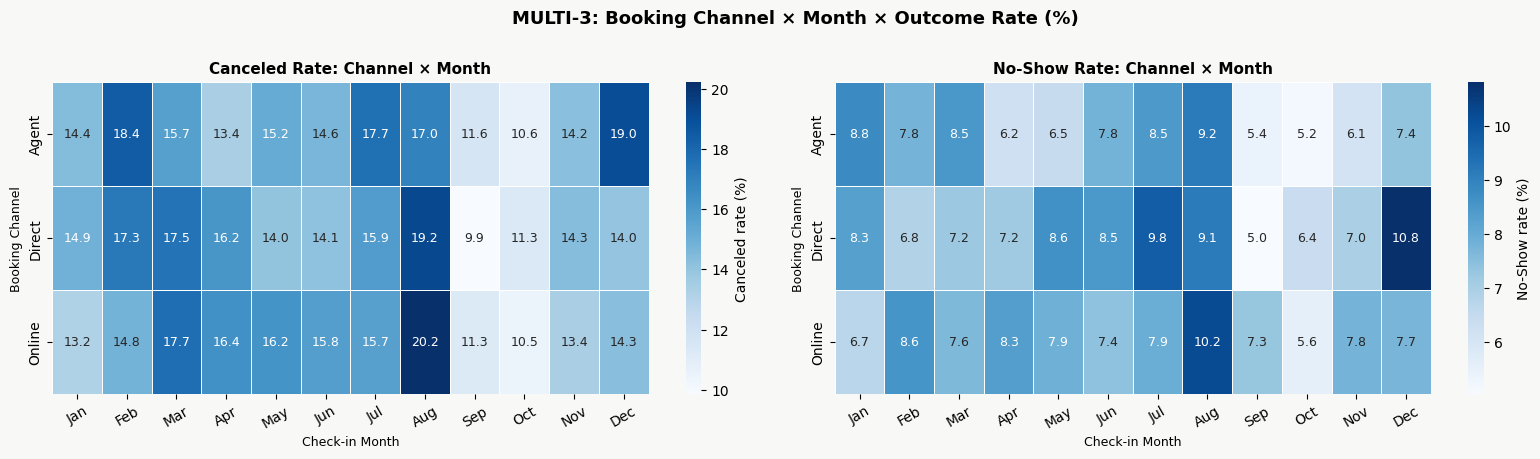

In [ ]:
# Booking Channel × Month × Cancellation Rate
# This Shows whether certain channel-month combinations drive disproportionate loss.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.5))
fig.patch.set_facecolor(BG)

for ax, status in zip([ax1, ax2], ['Canceled', 'No-Show']):
    pivot = df.groupby(['Booking_channel','checkin_month_name']).apply(
        lambda x: (x['Reservation_Status']==status).mean() * 100
    ).unstack(fill_value=0)
    pivot = pivot.reindex(columns=[m for m in MONTH_ORDER if m in pivot.columns])
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.5, annot_kws={'size': 9},
                cbar_kws={'label': f'{status} rate (%)'})
    ax.set_title(f'{status} Rate: Channel × Month', fontweight='bold', fontsize=11)
    ax.set_xlabel('Check-in Month', fontsize=9)
    ax.set_ylabel('Booking Channel', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('MULTI-3: Booking Channel × Month × Outcome Rate (%)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

FEATURE ENGINEERING

In [ ]:
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

val_clean  = pd.read_csv('Hotel-A-validation-clean.csv')
test_clean = pd.read_csv('Hotel-A-test-clean.csv')

# Convert date columns back to datetime
for split in [df, val_clean, test_clean]:
    split['checkin'] = pd.to_datetime(split['checkin'], errors='coerce')
    split['checkout'] = pd.to_datetime(split['checkout'], errors='coerce')
    split['booking'] = pd.to_datetime(split['booking'], errors='coerce')

print(f"df (train) : {df.shape}")
print(f"val_clean  : {val_clean.shape}")
print(f"test_clean : {test_clean.shape}")

df (train) : (26993, 34)
val_clean  : (2733, 34)
test_clean : (4291, 32)


In [ ]:
# 1. Date-derived features
# remaining date-based features are added.

for split in [df, val_clean, test_clean]:
    split['checkin_dayofweek']  = split['checkin'].dt.dayofweek
    split['booking_month']      = split['booking'].dt.month
    split['is_weekend_checkin'] = split['checkin_dayofweek'].isin([4, 5, 6]).astype(int)

print("Date features added:")
print(df[['lead_time', 'stay_nights', 'checkin_month',
          'checkin_dayofweek', 'booking_month', 'is_weekend_checkin']].head(3))


Date features added:
   lead_time  stay_nights  checkin_month  checkin_dayofweek  booking_month  \
0         41            1              7                  2              5   
1         36            1              7                  2              5   
2          3            4              7                  3              6   

   is_weekend_checkin  
0                   0  
1                   0  
2                   0  


In [ ]:
# 2. Composite features
for split in [df, val_clean, test_clean]:
    # Total number of guests in the booking
    split['total_guests'] = split['Adults'] + split['Children'] + split['Babies']

    # Actual room price after discount
    split['effective_rate'] = split['Room_Rate'] * (1 - split['Discount_Rate'] / 100)

    # Cost per person
    split['room_rate_per_guest'] = split['Room_Rate'] / split['total_guests'].replace(0, 1)

    # Whether any discount was applied
    split['discounted'] = (split['Discount_Rate'] > 0).astype(int)

print("Composite features added:")
print(df[['total_guests', 'effective_rate', 'room_rate_per_guest', 'discounted']].head(3))

Composite features added:
   total_guests  effective_rate  room_rate_per_guest  discounted
0             4           196.2            54.500000           1
1             6           185.0            30.833333           0
2             6           119.0            19.833333           0


In [ ]:
#3. Binary encoding
# Yes/No columns → 1/0
# Gender → Male=1, Female=0
binary_cols = ['Visted_Previously', 'Previous_Cancellations',
               'Required_Car_Parking', 'Use_Promotion']

for split in [df, val_clean, test_clean]:
    for col in binary_cols:
        split[col] = split[col].map({'Yes': 1, 'No': 0})
    split['Gender'] = split['Gender'].map({'M': 1, 'F': 0})

print("Binary encoding done:")
print(df[['Gender', 'Visted_Previously', 'Previous_Cancellations',
          'Required_Car_Parking', 'Use_Promotion']].head(3))



Binary encoding done:
   Gender  Visted_Previously  Previous_Cancellations  Required_Car_Parking  \
0       0                  0                       0                     1   
1       0                  0                       0                     1   
2       0                  0                       0                     1   

   Use_Promotion  
0              1  
1              0  
2              0  


In [ ]:
#4. Ordinal EncoDing
income_order = {'<25K': 0, '25K --50K': 1, '50K -- 100K': 2, '>100K': 3}
edu_order    = {'Mid-School': 0, 'High-School': 1, 'College': 2, 'Grad': 3}

for split in [df, val_clean, test_clean]:
    split['Income']            = split['Income'].map(income_order)
    split['Educational_Level'] = split['Educational_Level'].map(edu_order)

print("Ordinal encoding done:")
print(df[['Income', 'Educational_Level']].head(3))

Ordinal encoding done:
   Income  Educational_Level
0       0                  3
1       2                  0
2       0                  3


In [ ]:
#5. One-hot encoding
ohe_cols = ['Ethnicity', 'Country_region', 'Hotel_Type',
            'Meal_Type', 'Deposit_type', 'Booking_channel']

df         = pd.get_dummies(df,         columns=ohe_cols, drop_first=False, dtype=int)
val_clean  = pd.get_dummies(val_clean,  columns=ohe_cols, drop_first=False, dtype=int)
test_clean = pd.get_dummies(test_clean, columns=ohe_cols, drop_first=False, dtype=int)

new_cols = [c for c in df.columns if any(c.startswith(o + '_') for o in ohe_cols)]
print(f"One-hot encoding done — {len(new_cols)} new columns created:")
print(new_cols)

One-hot encoding done — 20 new columns created:
['Ethnicity_African American', 'Ethnicity_Asian American', 'Ethnicity_Caucasian', 'Ethnicity_Latino', 'Country_region_East', 'Country_region_North', 'Country_region_South', 'Country_region_West', 'Hotel_Type_Airport Hotels', 'Hotel_Type_City Hotel', 'Hotel_Type_Resort', 'Meal_Type_BB', 'Meal_Type_FB', 'Meal_Type_HB', 'Deposit_type_No Deposit', 'Deposit_type_Non-Refundable', 'Deposit_type_Refundable', 'Booking_channel_Agent', 'Booking_channel_Direct', 'Booking_channel_Online']


In [ ]:
#6. dropping columns that are not needed
drop_cols = [
    'Expected_checkin', 'Expected_checkout', 'Booking_date',
    'checkin', 'checkout', 'booking',
    'Reservation-id',
    'checkin_month_name',
]

df         = df.drop(columns=[c for c in drop_cols if c in df.columns])
val_clean  = val_clean.drop(columns=[c for c in drop_cols if c in val_clean.columns])
test_clean = test_clean.drop(columns=[c for c in drop_cols if c in test_clean.columns])

print("Dropped raw columns.")
print(f"Train shape after drop: {df.shape}")

Dropped raw columns.
Train shape after drop: (26993, 45)


In [ ]:
#column alignment
TARGET_COLS  = ['Reservation_Status', 'is_cancelled']
feature_cols = [c for c in df.columns if c not in TARGET_COLS]

for split in [val_clean, test_clean]:
    for col in feature_cols:
        if col not in split.columns:
            split[col] = 0

# Reorder to match train column order
val_clean  = val_clean[feature_cols + [c for c in TARGET_COLS if c in val_clean.columns]]
test_clean = test_clean[feature_cols]

print("Column alignment done:")
print(f"  Feature columns : {len(feature_cols)}")
print(f"  Train  : {df.shape}")
print(f"  Val    : {val_clean.shape}")
print(f"  Test   : {test_clean.shape}")
print(f"  NaNs in train features: {df[feature_cols].isnull().sum().sum()}")


Column alignment done:
  Feature columns : 43
  Train  : (26993, 45)
  Val    : (2733, 45)
  Test   : (4291, 43)
  NaNs in train features: 0


In [ ]:
#8. Feature scaling
scale_cols = [c for c in [
    'Age', 'Adults', 'Children', 'Babies',
    'Discount_Rate', 'Room_Rate',
    'lead_time', 'stay_nights',
    'total_guests', 'effective_rate', 'room_rate_per_guest',
    'checkin_month', 'checkin_dayofweek', 'booking_month',
    'Income', 'Educational_Level',
] if c in feature_cols]

scaler = StandardScaler()

# Fit only on train, then apply the same fitted scaler to val and test
df[scale_cols]         = scaler.fit_transform(df[scale_cols])
val_clean[scale_cols]  = scaler.transform(val_clean[scale_cols])
test_clean[scale_cols] = scaler.transform(test_clean[scale_cols])

# Save the fitted scaler — needed to transform new data at inference time
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Scaling done — {len(scale_cols)} columns scaled:")
print(scale_cols)
print("\nscaler.pkl saved.")

Scaling done — 16 columns scaled:
['Age', 'Adults', 'Children', 'Babies', 'Discount_Rate', 'Room_Rate', 'lead_time', 'stay_nights', 'total_guests', 'effective_rate', 'room_rate_per_guest', 'checkin_month', 'checkin_dayofweek', 'booking_month', 'Income', 'Educational_Level']

scaler.pkl saved.


In [ ]:
#9: Save engineered datasets
df.to_csv('train_engineered.csv',     index=False)
val_clean.to_csv('val_engineered.csv',  index=False)
test_clean.to_csv('test_engineered.csv', index=False)

print("Saved:")
print("  train_engineered.csv")
print("  val_engineered.csv")
print("  test_engineered.csv")



Saved:
  train_engineered.csv
  val_engineered.csv
  test_engineered.csv


MODELLING

In [ ]:
# Multiclass modeling setup (completed / cancelled / no show)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline

train_eng = pd.read_csv('train_engineered.csv')
val_eng = pd.read_csv('val_engineered.csv')
test_eng = pd.read_csv('test_engineered.csv')

def normalize_status(value):
    s = str(value).strip().lower()
    if s in {'check-out', 'check out', 'checkout', 'check-in', 'check in', 'completed'}:
        return 'completed'
    if s in {'canceled', 'cancelled'}:
        return 'cancelled'
    if s in {'no-show', 'no show', 'noshow'}:
        return 'no show'
    return 'completed'

for split in [train_eng, val_eng]:
    split['target_status'] = split['Reservation_Status'].apply(normalize_status)

if 'Reservation_Status' in test_eng.columns:
    test_eng['target_status'] = test_eng['Reservation_Status'].apply(normalize_status)

# Keep is_cancelled as an auxiliary feature; target is still 3-class target_status.
TARGET_COLS = ['Reservation_Status', 'target_status']
feature_cols = [c for c in train_eng.columns if c not in TARGET_COLS]

for split in [val_eng, test_eng]:
    missing_cols = [c for c in feature_cols if c not in split.columns]
    for col in missing_cols:
        split[col] = 0

X_train = train_eng[feature_cols].copy()
X_val = val_eng[feature_cols].copy()
X_test = test_eng[feature_cols].copy()

y_train_raw = train_eng['target_status'].copy()
y_val_raw = val_eng['target_status'].copy()

label_enc = LabelEncoder()
y_train = label_enc.fit_transform(y_train_raw)
y_val = label_enc.transform(y_val_raw)
class_names = list(label_enc.classes_)
num_classes = len(class_names)

BG = '#f8f8f6'

print('Datasets loaded and aligned:')
print(f"  Train shape      : {train_eng.shape}")
print(f"  Validation shape : {val_eng.shape}")
print(f"  Test shape       : {test_eng.shape}")
print(f"  Feature count    : {len(feature_cols)}")
print(f"  Classes          : {class_names}")
print(f"  Includes is_cancelled feature: {'is_cancelled' in feature_cols}")

print('\nTrain class distribution:')
print(y_train_raw.value_counts().to_string())
print('\nValidation class distribution:')
print(y_val_raw.value_counts().to_string())

Datasets loaded and aligned:
  Train shape      : (26993, 46)
  Validation shape : (2733, 46)
  Test shape       : (4291, 44)
  Feature count    : 44
  Classes          : ['cancelled', 'completed', 'no show']
  Includes is_cancelled feature: True

Train class distribution:
target_status
completed    20777
cancelled     4108
no show       2108

Validation class distribution:
target_status
completed    1602
cancelled     738
no show       393


In [ ]:
# Helper functions for multiclass evaluation

def compute_metrics(y_true, y_pred, y_prob):
    out = {
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision (macro)': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall (macro)': round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'F1 (macro)': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'F1 (weighted)': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

    try:
        y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
        auc_ovr = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr')
        out['ROC-AUC OvR (macro)'] = round(float(auc_ovr), 4)
    except ValueError:
        out['ROC-AUC OvR (macro)'] = np.nan

    return out


def evaluate_split(model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)
    return compute_metrics(y, pred, prob), pred, prob


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Helper functions ready.')

Helper functions ready.


In [ ]:
# IMPORTS
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

# EVALUATION FUNCTION
# =========================
def evaluate_split(model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)

    metrics = {
        'Accuracy': accuracy_score(y, pred),
        'Precision_macro': precision_score(y, pred, average='macro', zero_division=0),
        'Recall_macro': recall_score(y, pred, average='macro', zero_division=0),
        'F1_macro': f1_score(y, pred, average='macro'),
        'F1_weighted': f1_score(y, pred, average='weighted'),
        'ROC_AUC_macro': roc_auc_score(y, prob, multi_class='ovr', average='macro')
    }

    return metrics, pred, prob



# TRAINING SETUP
# =========================
results_table = []
model_store = {}

class_counts = pd.Series(y_train).value_counts().sort_index()
majority_count = int(class_counts.max())
ros_target = max(int(0.55 * majority_count), int(class_counts.min()))

ros_strategy = {cls: ros_target for cls, cnt in class_counts.items() if cnt < ros_target}
if len(ros_strategy) == 0:
    ros_strategy = 'not majority'

smote_k = 5

print('Resampling setup:')
print(f"  Original class counts (encoded): {class_counts.to_dict()}")
print(f"  RandomOverSampler strategy      : {ros_strategy}")
print(f"  SMOTE strategy                  : not majority (k_neighbors={smote_k})")



# MODEL CONFIGS
# =========================
model_configs = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=3000, solver='lbfgs', random_state=42),
        'param_grid': {
            'model__C': [0.2, 1.0, 3.0],
            'model__class_weight': [None, 'balanced'],
        },
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=42, n_jobs=-1),
        'param_grid': {
            'model__n_estimators': [300, 500],
            'model__max_depth': [None, 14],
            'model__min_samples_leaf': [1, 3],
            'model__class_weight': [None, 'balanced_subsample'],
        },
    },
    'XGBoost': {
        'estimator': XGBClassifier(
            objective='multi:softprob',
            num_class=num_classes,
            eval_metric='mlogloss',
            random_state=42,
            tree_method='hist',
            n_jobs=4,
            verbosity=0,
        ),
        'param_grid': {
            'model__n_estimators': [300, 500],
            'model__max_depth': [4, 6],
            'model__learning_rate': [0.03, 0.08],
            'model__subsample': [0.85, 1.0],
        },
    },
}


# TRAINING LOOP
# =========================
for model_name, cfg in model_configs.items():
    print(f"\nTuning {model_name}...")

    pipe = Pipeline(steps=[
        ('ros', RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)),
        ('smote', SMOTE(sampling_strategy='not majority', random_state=42, k_neighbors=smote_k)),
        ('model', cfg['estimator']),
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=cfg['param_grid'],
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=0,
        refit=True,
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    for split_name, X_split, y_split in [
        ('Train', X_train, y_train),
        ('Val', X_val, y_val)
    ]:
        m, pred, prob = evaluate_split(best_model, X_split, y_split)

        results_table.append({
            'Model': model_name,
            'Set': split_name,
            **m,
        })

    model_store[model_name] = {
        'model': best_model,
        'cv_f1_macro': round(float(grid.best_score_), 4),
        'best_params': grid.best_params_,
    }

    print(f"  best params : {grid.best_params_}")
    print(f"  CV macro F1 : {grid.best_score_:.4f}")



# RESULTS TABLE
# =========================
df_results = pd.DataFrame(results_table)

print('\nTraining and tuning complete.')
print(df_results)

Resampling setup:
  Original class counts (encoded): {0: 4108, 1: 20777, 2: 2108}
  RandomOverSampler strategy      : {0: 11427, 2: 11427}
  SMOTE strategy                  : not majority (k_neighbors=5)

Tuning Logistic Regression...
  best params : {'model__C': 0.2, 'model__class_weight': None}
  CV macro F1 : 0.6463

Tuning Random Forest...
  best params : {'model__class_weight': 'balanced_subsample', 'model__max_depth': 14, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}
  CV macro F1 : 0.6377

Tuning XGBoost...
  best params : {'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 500, 'model__subsample': 1.0}
  CV macro F1 : 0.6606

Training and tuning complete.
                 Model    Set  Accuracy  Precision_macro  Recall_macro  \
0  Logistic Regression  Train  0.871411         0.689563      0.685328   
1  Logistic Regression    Val  0.760337         0.681276      0.676797   
2        Random Forest  Train  0.998889         0.997026      0.99579

In [ ]:
# MODEL COMPARISON SUMMARY

print('VALIDATION RESULTS (multiclass, resampling, macro-F1 focus)')
print('=' * 120)

# Filter validation results
val_view = df_results[df_results['Set'] == 'Val'].copy()

# Rename columns for clean display (so your original labels work)
val_view = val_view.rename(columns={
    'precision_macro': 'Precision_macro',
    'recall_macro': 'Recall_macro',
    'f1_macro': 'F1_macro',
    'f1_weighted': 'F1_weighted',
    'roc_auc_ovr': 'ROC_AUC_macro'
})

# Print table
print(val_view[['Model', 'Accuracy', 'Precision_macro', 'Recall_macro',
                'F1_macro', 'F1_weighted', 'ROC_AUC_macro']].to_string(index=False))

# BEST MODEL SELECTION
best_row = val_view.sort_values(
    ['F1_macro', 'F1_weighted', 'Accuracy'],
    ascending=False
).iloc[0]

best_label = best_row['Model']
best_model_obj = model_store[best_label]['model']

print('\nBest model selection criterion: highest Validation macro F1')
print(f"Selected model: {best_label}")

print(
    f"Validation metrics -> "
    f"Accuracy: {best_row['Accuracy']}, "
    f"Precision(macro): {best_row['Precision_macro']}, "
    f"Recall(macro): {best_row['Recall_macro']}, "
    f"F1(macro): {best_row['F1_macro']}, "
    f"F1(weighted): {best_row['F1_weighted']}, "
    f"ROC-AUC OvR: {best_row['ROC_AUC_macro']}"
)

#HYPERPARAMETERS
print('\nBest hyperparameters by model:')
for model_name, meta in model_store.items():
    print(f"  {model_name}: {meta['best_params']}")

VALIDATION RESULTS (multiclass, resampling, macro-F1 focus)
              Model  Accuracy  Precision_macro  Recall_macro  F1_macro  F1_weighted  ROC_AUC_macro
Logistic Regression  0.760337         0.681276      0.676797  0.604770     0.743281       0.917027
      Random Forest  0.841200         0.675816      0.671542  0.653322     0.818407       0.917282
            XGBoost  0.786315         0.671240      0.671594  0.653713     0.790087       0.915238

Best model selection criterion: highest Validation macro F1
Selected model: XGBoost
Validation metrics -> Accuracy: 0.7863154043175997, Precision(macro): 0.6712397593445981, Recall(macro): 0.6715936752242841, F1(macro): 0.6537128261266193, F1(weighted): 0.7900873409408933, ROC-AUC OvR: 0.9152383928571511

Best hyperparameters by model:
  Logistic Regression: {'model__C': 0.2, 'model__class_weight': None}
  Random Forest: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 14, 'model__min_samples_leaf': 3, 'model__n_estimato

In [ ]:
# 5-fold cross-validation comparison on training data (multiclass)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('5-Fold Cross-Validation on Training Set')
print('-' * 84)
print(f"{'Model':<22} | {'CV Macro-F1':>11} | {'CV Weighted-F1':>14} | {'CV Accuracy':>11}")
print('-' * 84)

for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    model = model_store[name]['model']
    f1_macro = cross_val_score(model, X_train, y_train, cv=cv5, scoring='f1_macro', n_jobs=-1).mean()
    f1_weighted = cross_val_score(model, X_train, y_train, cv=cv5, scoring='f1_weighted', n_jobs=-1).mean()
    acc = cross_val_score(model, X_train, y_train, cv=cv5, scoring='accuracy', n_jobs=-1).mean()
    print(f"{name:<22} | {f1_macro:>11.4f} | {f1_weighted:>14.4f} | {acc:>11.4f}")

print('-' * 84)
print('CV metrics are computed with resampling inside each training fold.')

5-Fold Cross-Validation on Training Set
------------------------------------------------------------------------------------
Model                  | CV Macro-F1 | CV Weighted-F1 | CV Accuracy
------------------------------------------------------------------------------------
Logistic Regression    |      0.6463 |         0.8790 |      0.8779
Random Forest          |      0.6377 |         0.8979 |      0.9159
XGBoost                |      0.6606 |         0.8914 |      0.8889
------------------------------------------------------------------------------------
CV metrics are computed with resampling inside each training fold.


In [ ]:
# Classification report for selected best model on validation set
val_pred_best = best_model_obj.predict(X_val)
val_prob_best = best_model_obj.predict_proba(X_val)

print(f"Classification Report - {best_label} (Validation)")
print('-' * 72)
print(classification_report(
    y_val,
    val_pred_best,
    target_names=class_names,
    zero_division=0,
))

cm_best = confusion_matrix(y_val, val_pred_best, labels=np.arange(num_classes))
cm_df = pd.DataFrame(cm_best, index=class_names, columns=class_names)
print('Confusion matrix counts (rows=true, cols=pred):')
print(cm_df)

Classification Report - XGBoost (Validation)
------------------------------------------------------------------------
              precision    recall  f1-score   support

   cancelled       0.66      0.43      0.52       738
   completed       1.00      1.00      1.00      1602
     no show       0.35      0.59      0.44       393

    accuracy                           0.79      2733
   macro avg       0.67      0.67      0.65      2733
weighted avg       0.82      0.79      0.79      2733

Confusion matrix counts (rows=true, cols=pred):
           cancelled  completed  no show
cancelled        317          0      421
completed          0       1602        0
no show          163          0      230


In [ ]:
# Per-class validation metrics for selected best model
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, support = precision_recall_fscore_support(
    y_val,
    val_pred_best,
    labels=np.arange(num_classes),
    zero_division=0,
)

per_class_metrics = pd.DataFrame({
    'Class': class_names,
    'Precision': np.round(prec, 4),
    'Recall': np.round(rec, 4),
    'F1': np.round(f1, 4),
    'Support': support,
})

print('Per-class validation metrics:')
print(per_class_metrics.to_string(index=False))

Per-class validation metrics:
    Class  Precision  Recall     F1  Support
cancelled     0.6604  0.4295 0.5205      738
completed     1.0000  1.0000 1.0000     1602
  no show     0.3533  0.5852 0.4406      393


In [ ]:
# Validation ranking table (all tuned models)
val_rank = df_results[df_results['Set'] == 'Val'].copy()
val_rank = val_rank.sort_values(['F1_macro', 'F1_weighted', 'Accuracy'], ascending=False)

print('Validation model ranking:')
print(val_rank[['Model', 'Accuracy', 'Precision_macro', 'Recall_macro',
                'F1_macro', 'F1_weighted', 'ROC_AUC_macro']].to_string(index=False))

Validation model ranking:
              Model  Accuracy  Precision_macro  Recall_macro  F1_macro  F1_weighted  ROC_AUC_macro
            XGBoost  0.786315         0.671240      0.671594  0.653713     0.790087       0.915238
      Random Forest  0.841200         0.675816      0.671542  0.653322     0.818407       0.917282
Logistic Regression  0.760337         0.681276      0.676797  0.604770     0.743281       0.917027


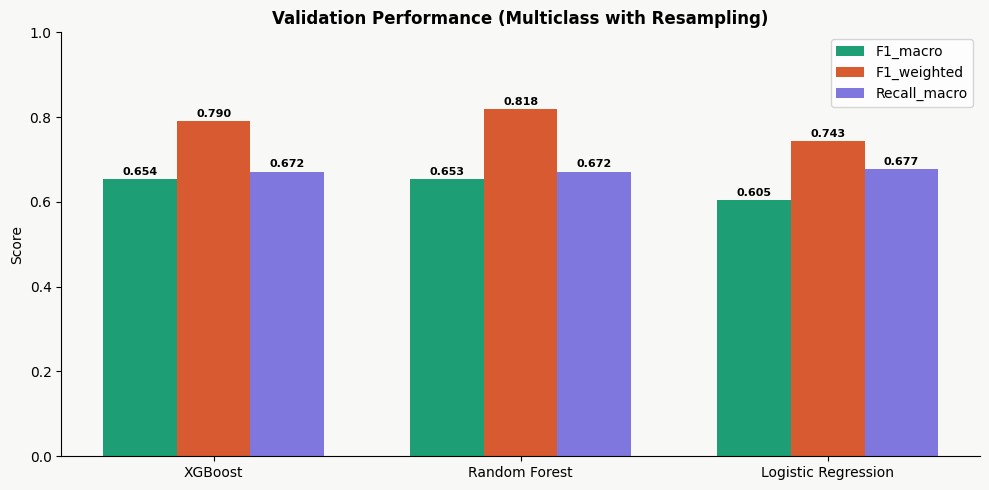

In [ ]:
# Chart 1 - Validation macro F1, weighted F1, recall by model
val_plot = df_results[df_results['Set'] == 'Val'].copy()
val_plot = val_plot.sort_values('F1_macro', ascending=False).reset_index(drop=True)

metric_cols = ['F1_macro', 'F1_weighted', 'Recall_macro']
x = np.arange(len(val_plot))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)

colors = ['#1D9E75', '#D85A30', '#7F77DD']
for i, metric in enumerate(metric_cols):
    bars = ax.bar(x + (i - 1) * width, val_plot[metric], width, label=metric, color=colors[i])
    for b, v in zip(bars, val_plot[metric]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005, f"{v:.3f}",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(val_plot['Model'], rotation=0)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Validation Performance (Multiclass with Resampling)', fontweight='bold')
ax.legend()
ax.set_facecolor(BG)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

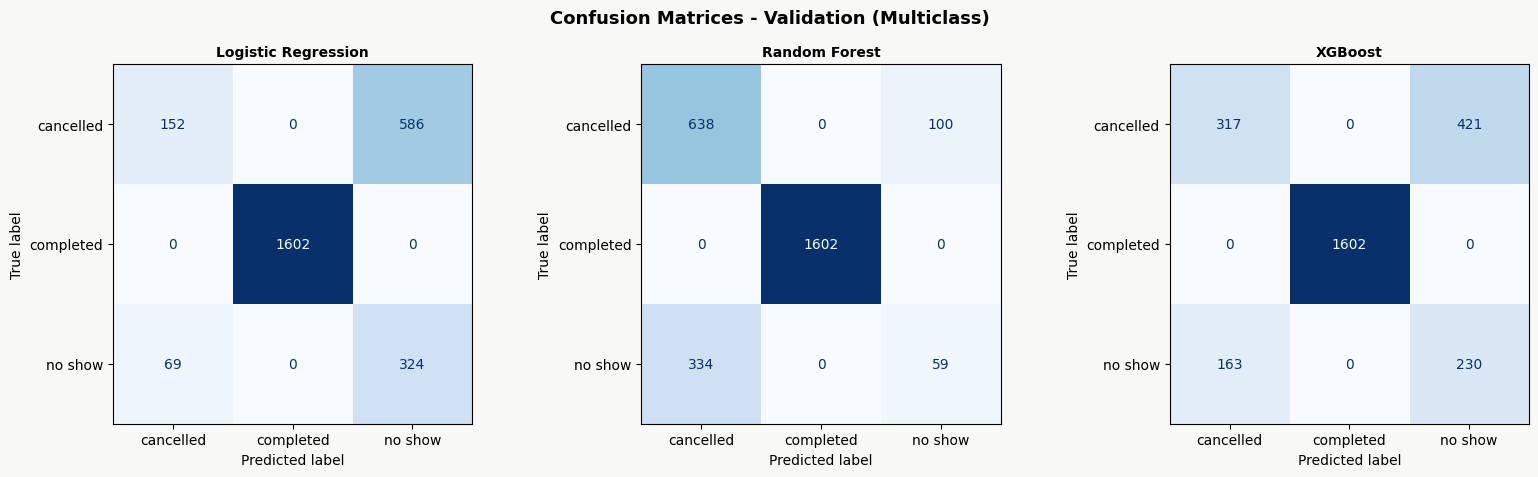

In [ ]:
# Chart 2 - Confusion matrices for all tuned models on validation (multiclass)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
fig.patch.set_facecolor(BG)
fig.suptitle('Confusion Matrices - Validation (Multiclass)', fontweight='bold', fontsize=13)

for ax, (name, meta) in zip(axes, model_store.items()):
    pred = meta['model'].predict(X_val)
    cm = confusion_matrix(y_val, pred, labels=np.arange(num_classes))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_facecolor(BG)

plt.tight_layout()
plt.show()

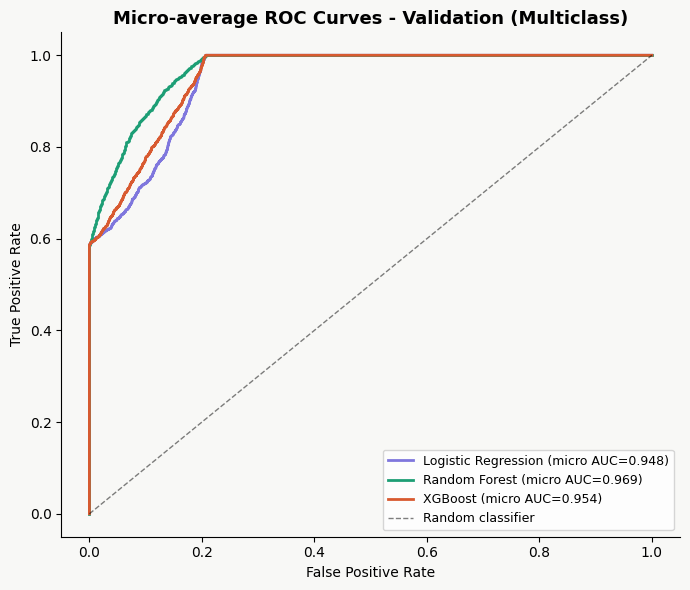

In [ ]:
# Chart 3 - Micro-average ROC curves for all tuned models
y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(BG)

colors = {'Logistic Regression': '#7F77DD', 'Random Forest': '#1D9E75', 'XGBoost': '#D85A30'}
for name, meta in model_store.items():
    prob = meta['model'].predict_proba(X_val)
    fpr, tpr, _ = roc_curve(y_val_bin.ravel(), prob.ravel())
    auc_micro = roc_auc_score(y_val_bin, prob, average='micro', multi_class='ovr')
    ax.plot(fpr, tpr, linewidth=2, color=colors[name], label=f"{name} (micro AUC={auc_micro:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.set_title('Micro-average ROC Curves - Validation (Multiclass)', fontweight='bold', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9)
ax.set_facecolor(BG)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

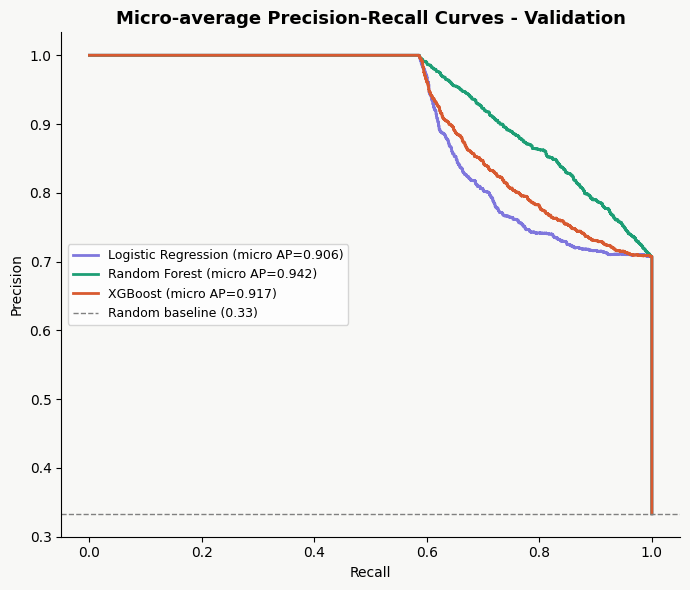

In [ ]:
# Chart 4 - Micro-average Precision-Recall curves for all tuned models
y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(BG)

colors = {'Logistic Regression': '#7F77DD', 'Random Forest': '#1D9E75', 'XGBoost': '#D85A30'}
for name, meta in model_store.items():
    prob = meta['model'].predict_proba(X_val)
    prec, rec, _ = precision_recall_curve(y_val_bin.ravel(), prob.ravel())
    ap_micro = average_precision_score(y_val_bin, prob, average='micro')
    ax.plot(rec, prec, linewidth=2, color=colors[name], label=f"{name} (micro AP={ap_micro:.3f})")

baseline = y_val_bin.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, label=f'Random baseline ({baseline:.2f})')
ax.set_title('Micro-average Precision-Recall Curves - Validation', fontweight='bold', fontsize=13)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
ax.set_facecolor(BG)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

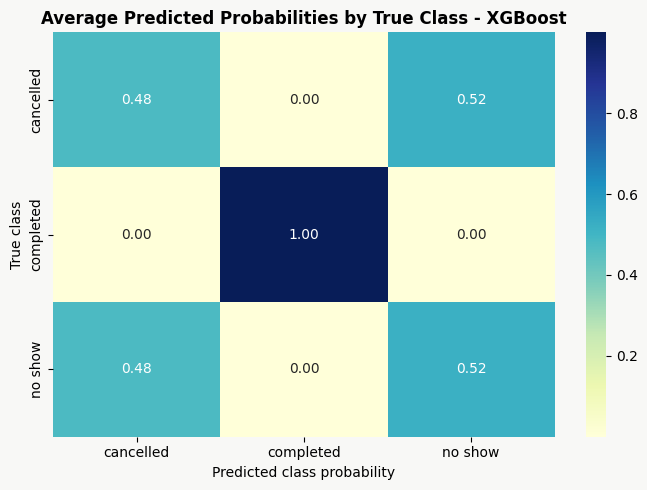

In [ ]:
# Chart 5 - Average predicted class probabilities by true class
prob_df = pd.DataFrame(val_prob_best, columns=class_names)
prob_df['true_class'] = [class_names[i] for i in y_val]

mean_probs = prob_df.groupby('true_class')[class_names].mean().reindex(class_names)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(BG)
sns.heatmap(mean_probs, annot=True, fmt='.2f', cmap='YlGnBu', cbar=True, ax=ax)
ax.set_title(f'Average Predicted Probabilities by True Class - {best_label}', fontweight='bold', fontsize=12)
ax.set_xlabel('Predicted class probability')
ax.set_ylabel('True class')
plt.tight_layout()
plt.show()

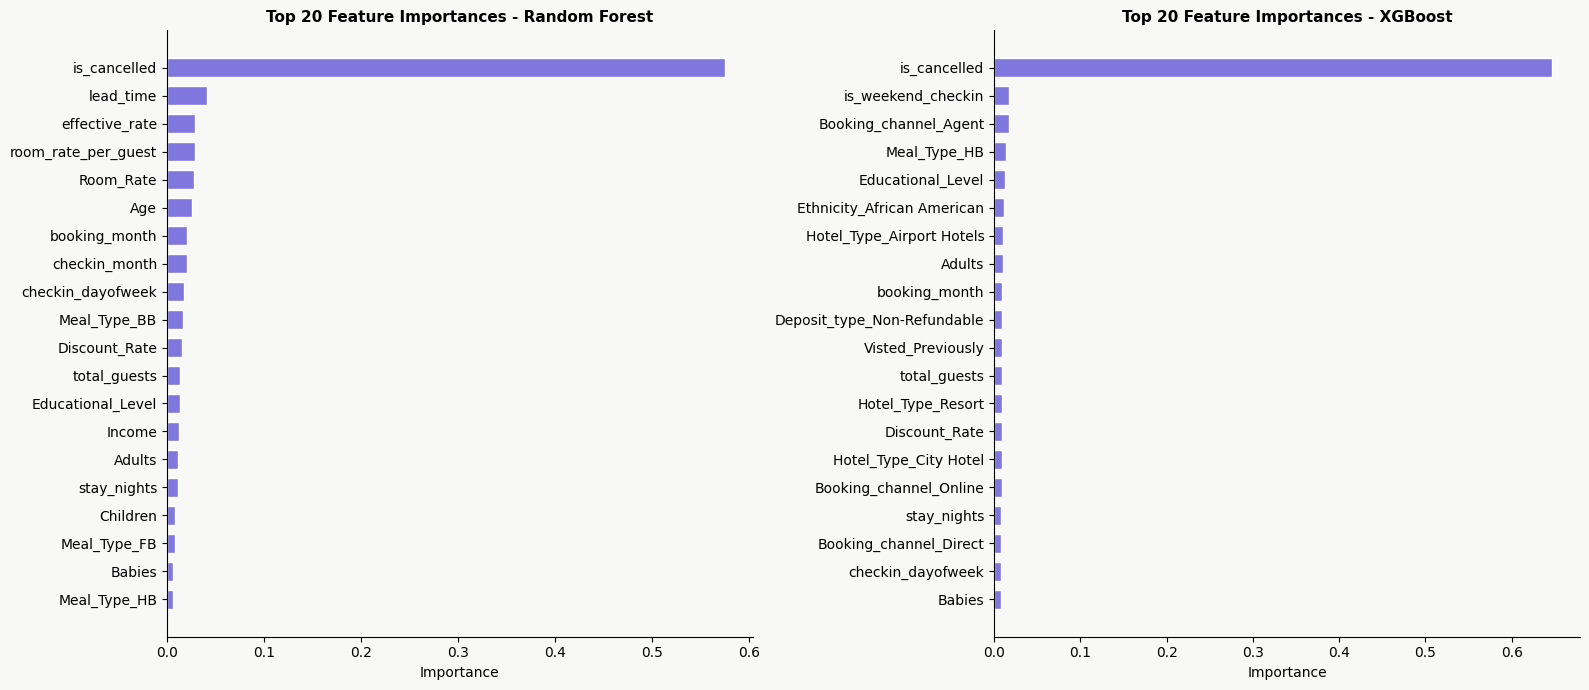

In [ ]:
# Chart 6 - Feature importance (Random Forest and XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    clf = model_store[model_name]['model'].named_steps['model']
    imp = pd.Series(clf.feature_importances_, index=feature_cols)
    top20 = imp.sort_values(ascending=True).tail(20)
    ax.barh(top20.index, top20.values, color='#7F77DD', edgecolor='white', height=0.7)
    ax.set_title(f'Top 20 Feature Importances - {model_name}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance')
    ax.set_facecolor(BG)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Save selected multiclass model artifact
import pickle

artifact = {
    'model_name': best_label,
    'model': best_model_obj,
    'feature_columns': feature_cols,
    'class_names': class_names,
}

with open('best_model_artifact.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print('Saved model artifact: best_model_artifact.pkl')
print(f"  Model: {best_label}")
print(f"  Classes: {class_names}")
print(f"  Features: {len(feature_cols)}")

Saved model artifact: best_model_artifact.pkl
  Model: XGBoost
  Classes: ['cancelled', 'completed', 'no show']
  Features: 44


In [ ]:
# Final multiclass predictions on test set using selected model
test_probs = best_model_obj.predict_proba(X_test)
test_preds = best_model_obj.predict(X_test)
test_pred_labels = label_enc.inverse_transform(test_preds)

test_output = pd.DataFrame({
    'predicted_status': test_pred_labels,
})

for i, cls in enumerate(class_names):
    cls_col = f"prob_{cls.replace(' ', '_')}"
    test_output[cls_col] = np.round(test_probs[:, i], 4)

test_output.to_csv('test_predictions.csv', index=False)

print(f"Best model used     : {best_label}")
print(f"Total test bookings : {len(test_preds):,}")
print('Predicted class distribution:')
print(test_output['predicted_status'].value_counts().to_string())
print('Saved: test_predictions.csv')

Best model used     : XGBoost
Total test bookings : 4,291
Predicted class distribution:
predicted_status
completed    4291
Saved: test_predictions.csv


Revenue loss Analysis
(Calculates total revenue lost due to cancellations and no-shows, broken down by customer demographics and geography.)

In [ ]:
# Revenue Loss Analysis

# Load cleaned training data
df_rev = pd.read_csv('Hotel-A-train-clean.csv')

BG = '#f8f8f6'
STATUS_ORDER = ['Check-Out', 'Canceled', 'No-Show']
PALETTE = {'Check-Out': '#1D9E75', 'Canceled': '#D85A30', 'No-Show': '#7F77DD'}

# Revenue calculation
df_rev['total_revenue'] = (
    df_rev['Room_Rate'] *
    df_rev['stay_nights'] *
    (1 - df_rev['Discount_Rate'] / 100)
)

# Check-Out contributes zero to lost revenue, while Canceled and No-Show are full loss.
loss_weight_map = {'Check-Out': 0.0, 'Canceled': 1.0, 'No-Show': 1.0}
df_rev['loss_weight'] = df_rev['Reservation_Status'].map(loss_weight_map).fillna(0.0)
df_rev['revenue_lost'] = df_rev['total_revenue'] * df_rev['loss_weight']

# Age group segmentation
df_rev['Age_Group'] = pd.cut(
    df_rev['Age'],
    bins=[17, 30, 45, 60, 70],
    labels=['18-30', '31-45', '46-60', '61-70']
)

# Summary statistics
total_revenue = df_rev['total_revenue'].sum()
total_lost = df_rev['revenue_lost'].sum()
pct_lost = total_lost / total_revenue * 100

status_total_revenue = (
    df_rev.groupby('Reservation_Status')['total_revenue']
    .sum()
    .reindex(STATUS_ORDER, fill_value=0)
)
status_lost_revenue = (
    df_rev.groupby('Reservation_Status')['revenue_lost']
    .sum()
    .reindex(STATUS_ORDER, fill_value=0)
)
status_counts = df_rev['Reservation_Status'].value_counts().reindex(STATUS_ORDER, fill_value=0)

n_loss_bookings = int(status_counts['Canceled'] + status_counts['No-Show'])
avg_lost = total_lost / n_loss_bookings if n_loss_bookings > 0 else 0


print('REVENUE LOSS SUMMARY')
print('=' * 65)
print(f'Total potential revenue   : ${total_revenue:>14,.2f}')
print(f'Total revenue lost        : ${total_lost:>14,.2f}')
print(f'Percentage lost           : {pct_lost:>13.1f}%')
print(f'Loss bookings (C+NS)      : {n_loss_bookings:>14,}')
print(f'Average loss per booking  : ${avg_lost:>14,.2f}')

print('\nPer-class revenue breakdown:')
for status in STATUS_ORDER:
    class_total = status_total_revenue[status]
    class_lost = status_lost_revenue[status]
    class_n = int(status_counts[status])
    class_loss_pct = (class_lost / total_lost * 100) if total_lost > 0 else 0
    print(
        f'  {status:<9} | bookings={class_n:>6,} | '
        f'potential=${class_total:>12,.2f} | lost=${class_lost:>12,.2f} '
        f'({class_loss_pct:>5.1f}% of total lost)'
    )

REVENUE LOSS SUMMARY
Total potential revenue   : $  7,553,903.05
Total revenue lost        : $  1,737,902.55
Percentage lost           :          23.0%
Loss bookings (C+NS)      :          6,216
Average loss per booking  : $        279.59

Per-class revenue breakdown:
  Check-Out | bookings=20,777 | potential=$5,816,000.50 | lost=$        0.00 (  0.0% of total lost)
  Canceled  | bookings= 4,108 | potential=$1,150,239.60 | lost=$1,150,239.60 ( 66.2% of total lost)
  No-Show   | bookings= 2,108 | potential=$  587,662.95 | lost=$  587,662.95 ( 33.8% of total lost)


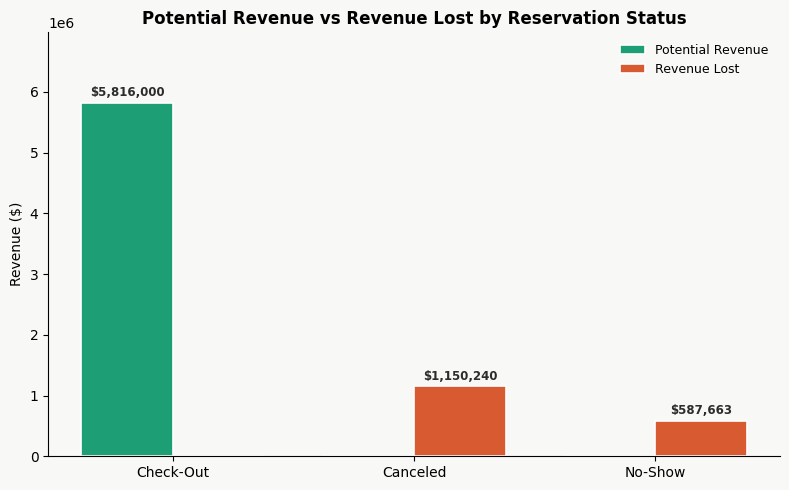

In [ ]:
# Chart 1 - Potential vs Lost Revenue by Reservation Status

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)

x = np.arange(len(STATUS_ORDER))
width = 0.38

total_vals = [
    status_total_revenue[s] if s in ['Check-Out', 'Checked-Out', 'Stayed'] else 0
    for s in STATUS_ORDER
]

lost_vals = [
    0 if s in ['Check-Out', 'Checked-Out', 'Stayed'] else status_lost_revenue[s]
    for s in STATUS_ORDER
]

#  PLOT
bars_total = ax.bar(
    x - width / 2,
    total_vals,
    width=width,
    color='#1D9E75',
    edgecolor='white',
    linewidth=1.2,
    label='Potential Revenue',
)

bars_lost = ax.bar(
    x + width / 2,
    lost_vals,
    width=width,
    color='#D85A30',
    edgecolor='white',
    linewidth=1.2,
    label='Revenue Lost',
)

#LABELS
max_val = max(total_vals + lost_vals)

for bars in [bars_total, bars_lost]:
    for bar in bars:
        v = bar.get_height()
        if v > 0:  # avoid showing $0 labels
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                v + (max_val * 0.01),
                f'${v:,.0f}',
                ha='center',
                va='bottom',
                fontsize=8.5,
                fontweight='bold',
                color='#2C2C2A',
            )

# AXIS & STYLE
ax.set_xticks(x)
ax.set_xticklabels(STATUS_ORDER)
ax.set_title('Potential Revenue vs Revenue Lost by Reservation Status',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Revenue ($)')
ax.set_ylim(0, max_val * 1.2)

ax.legend(frameon=False, fontsize=9)
ax.set_facecolor(BG)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

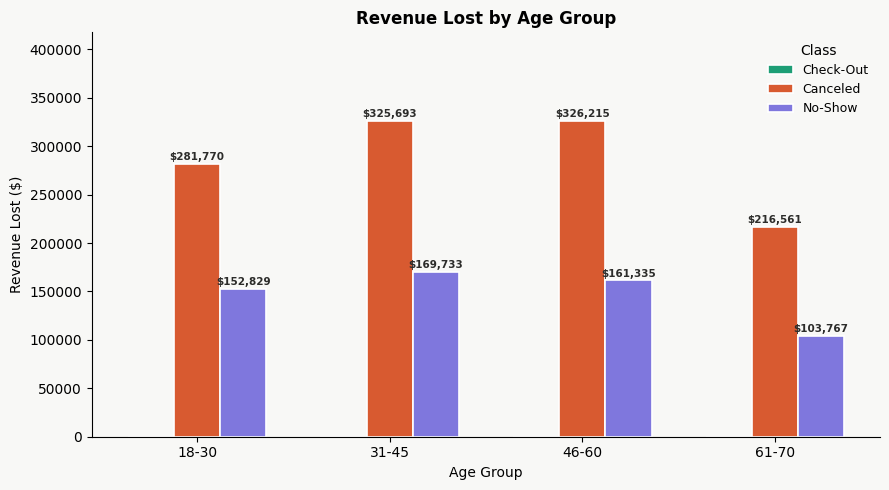

Age group insights (Canceled vs No-Show):
  18-30: Canceled=$  281,770, No-Show=$  152,829, Total=$   434,599
  31-45: Canceled=$  325,693, No-Show=$  169,733, Total=$   495,426
  46-60: Canceled=$  326,215, No-Show=$  161,335, Total=$   487,549
  61-70: Canceled=$  216,561, No-Show=$  103,767, Total=$   320,328


In [ ]:
# Chart 2 - Revenue Lost by Age Group and Reservation Status
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)

age_order = ['18-30', '31-45', '46-60', '61-70']
age_lost_mix = (
    df_rev.pivot_table(
        index='Age_Group',
        columns='Reservation_Status',
        values='revenue_lost',
        aggfunc='sum',
        fill_value=0,
        observed=True,
    )
    .reindex(age_order)
    .reindex(columns=STATUS_ORDER, fill_value=0)
    .fillna(0)
)

x = np.arange(len(age_lost_mix.index))
width = 0.24

for i, status in enumerate(STATUS_ORDER):
    vals = age_lost_mix[status].values
    bars = ax.bar(
        x + (i - 1) * width,
        vals,
        width=width,
        color=PALETTE[status],
        edgecolor='white',
        linewidth=1.2,
        label=status,
    )
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                v + 2000,
                f'${v:,.0f}',
                ha='center',
                va='bottom',
                fontsize=7.5,
                fontweight='bold',
                color='#2C2C2A',
            )

ax.set_xticks(x)
ax.set_xticklabels(age_lost_mix.index.astype(str))
ax.set_title('Revenue Lost by Age Group', fontweight='bold', fontsize=12)
ax.set_xlabel('Age Group')
ax.set_ylabel('Revenue Lost ($)')
ax.set_ylim(0, max(1, age_lost_mix.values.max()) * 1.28)
ax.legend(frameon=False, fontsize=9, title='Class')
ax.set_facecolor(BG)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Age group insights (Canceled vs No-Show):')
for grp in age_lost_mix.index:
    canceled_val = age_lost_mix.loc[grp, 'Canceled']
    no_show_val = age_lost_mix.loc[grp, 'No-Show']
    total_val = age_lost_mix.loc[grp].sum()
    print(
        f'  {grp}: Canceled=${canceled_val:>9,.0f}, '
        f'No-Show=${no_show_val:>9,.0f}, Total=${total_val:>10,.0f}'
    )

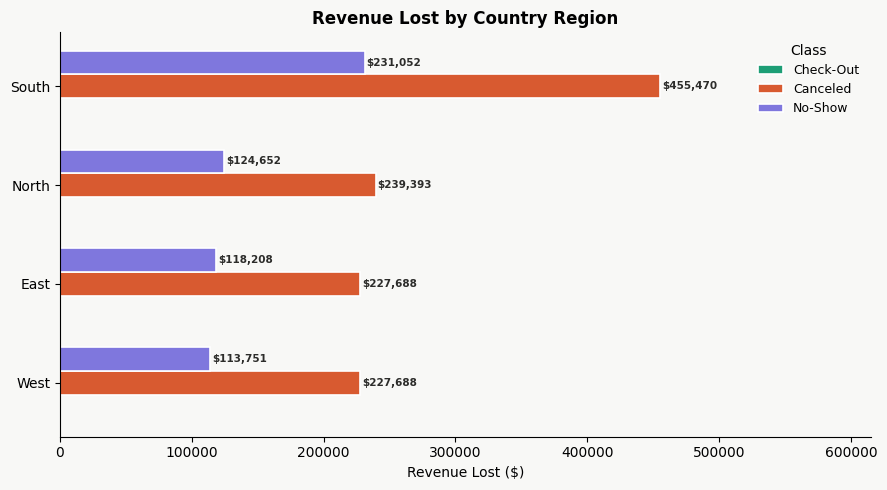

Region insights (Canceled vs No-Show):
  South   : Canceled=$  455,470, No-Show=$  231,052, Total=$   686,522
  North   : Canceled=$  239,393, No-Show=$  124,652, Total=$   364,045
  East    : Canceled=$  227,688, No-Show=$  118,208, Total=$   345,896
  West    : Canceled=$  227,688, No-Show=$  113,751, Total=$   341,439


In [ ]:
# Chart 3 - Revenue Lost by Country Region and Reservation Status
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)

reg_lost_mix = (
    df_rev.pivot_table(
        index='Country_region',
        columns='Reservation_Status',
        values='revenue_lost',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(columns=STATUS_ORDER, fill_value=0)
    .fillna(0)
)
reg_lost_mix['Total'] = reg_lost_mix.sum(axis=1)
reg_lost_mix = reg_lost_mix.sort_values('Total', ascending=True).drop(columns='Total')

y = np.arange(len(reg_lost_mix.index))
height = 0.24

for i, status in enumerate(STATUS_ORDER):
    vals = reg_lost_mix[status].values
    bars = ax.barh(
        y + (i - 1) * height,
        vals,
        height=height,
        color=PALETTE[status],
        edgecolor='white',
        linewidth=1.2,
        label=status,
    )
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(
                v + 1500,
                bar.get_y() + bar.get_height() / 2,
                f'${v:,.0f}',
                va='center',
                fontsize=7.5,
                fontweight='bold',
                color='#2C2C2A',
            )

ax.set_yticks(y)
ax.set_yticklabels(reg_lost_mix.index)
ax.set_title('Revenue Lost by Country Region', fontweight='bold', fontsize=12)
ax.set_xlabel('Revenue Lost ($)')
ax.set_xlim(0, max(1, reg_lost_mix.values.max()) * 1.35)
ax.legend(frameon=False, fontsize=9, title='Class')
ax.set_facecolor(BG)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Region insights (Canceled vs No-Show):')
reg_total = reg_lost_mix[['Canceled', 'No-Show']].sum(axis=1).sort_values(ascending=False)
for reg in reg_total.index:
    canceled_val = reg_lost_mix.loc[reg, 'Canceled']
    no_show_val = reg_lost_mix.loc[reg, 'No-Show']
    total_val = canceled_val + no_show_val
    print(
        f'  {reg:<8}: Canceled=${canceled_val:>9,.0f}, '
        f'No-Show=${no_show_val:>9,.0f}, Total=${total_val:>10,.0f}'
    )

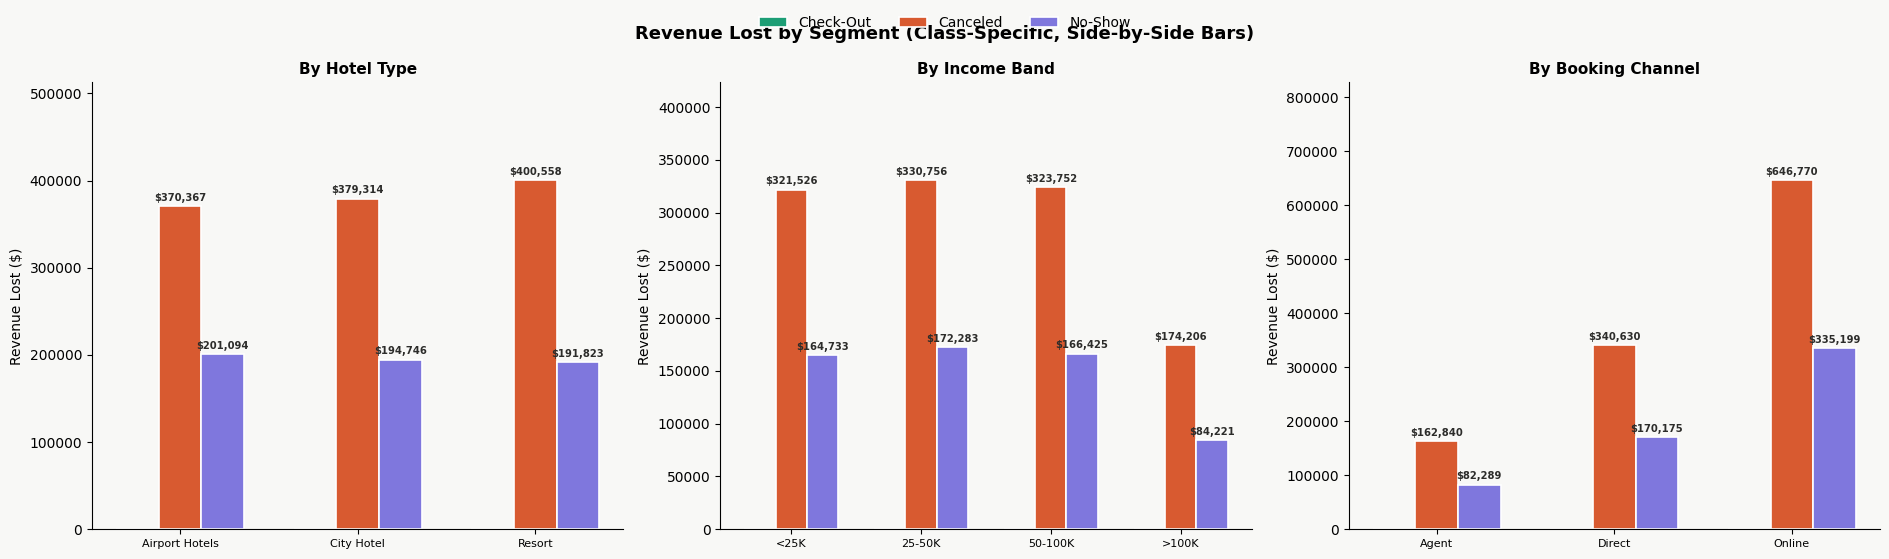


Hotel Type (Canceled vs No-Show):
  Airport Hotels    : Canceled=$  370,367, No-Show=$  201,094, Total=$   571,461
  City Hotel        : Canceled=$  379,314, No-Show=$  194,746, Total=$   574,060
  Resort            : Canceled=$  400,558, No-Show=$  191,823, Total=$   592,381

Income Band (Canceled vs No-Show):
  <25K           : Canceled=$  321,526, No-Show=$  164,733, Total=$   486,259
  25K --50K      : Canceled=$  330,756, No-Show=$  172,283, Total=$   503,039
  50K -- 100K    : Canceled=$  323,752, No-Show=$  166,425, Total=$   490,177
  >100K          : Canceled=$  174,206, No-Show=$   84,221, Total=$   258,428

Booking Channel (Canceled vs No-Show):
  Agent     : Canceled=$  162,840, No-Show=$   82,289, Total=$   245,128
  Direct    : Canceled=$  340,630, No-Show=$  170,175, Total=$   510,805
  Online    : Canceled=$  646,770, No-Show=$  335,199, Total=$   981,969


In [ ]:
# Charts 4, 5, 6 - Revenue Lost by Segment and Reservation Status
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
fig.patch.set_facecolor(BG)
fig.suptitle(
    'Revenue Lost by Segment (Class-Specific, Side-by-Side Bars)',
    fontweight='bold',
    fontsize=13,
)

def class_lost_mix(index_col, order=None):
    mix = (
        df_rev.pivot_table(
            index=index_col,
            columns='Reservation_Status',
            values='revenue_lost',
            aggfunc='sum',
            fill_value=0,
        )
        .reindex(columns=STATUS_ORDER, fill_value=0)
        .fillna(0)
    )
    if order is not None:
        mix = mix.reindex(order)
    return mix.fillna(0)

def draw_grouped_loss(ax, mix, title, xticklabels=None):
    x = np.arange(len(mix.index))
    width = 0.24

    for i, status in enumerate(STATUS_ORDER):
        vals = mix[status].values
        bars = ax.bar(
            x + (i - 1) * width,
            vals,
            width=width,
            color=PALETTE[status],
            edgecolor='white',
            linewidth=1.2,
            label=status,
        )
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    v + max(500, mix.values.max() * 0.01),
                    f'${v:,.0f}',
                    ha='center',
                    va='bottom',
                    fontsize=7.2,
                    fontweight='bold',
                    color='#2C2C2A',
                )

    ax.set_xticks(x)
    if xticklabels is None:
        ax.set_xticklabels(mix.index, fontsize=8)
    else:
        ax.set_xticklabels(xticklabels, fontsize=8)

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Revenue Lost ($)')
    ax.set_ylim(0, max(1, mix.values.max()) * 1.28)
    ax.set_facecolor(BG)
    ax.spines[['top', 'right']].set_visible(False)

# Chart 4 - Hotel Type
ht_lost_mix = class_lost_mix('Hotel_Type')
draw_grouped_loss(axes[0], ht_lost_mix, 'By Hotel Type')

# Chart 5 - Income Band
inc_order = ['<25K', '25K --50K', '50K -- 100K', '>100K']
inc_lost_mix = class_lost_mix('Income', order=inc_order)
draw_grouped_loss(
    axes[1],
    inc_lost_mix,
    'By Income Band',
    xticklabels=['<25K', '25-50K', '50-100K', '>100K'],
)

# Chart 6 - Booking Channel
ch_lost_mix = class_lost_mix('Booking_channel')
draw_grouped_loss(axes[2], ch_lost_mix, 'By Booking Channel')

handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

# Print summary for all 3
print('\nHotel Type (Canceled vs No-Show):')
for ht in ht_lost_mix.index:
    canceled_val = ht_lost_mix.loc[ht, 'Canceled']
    no_show_val = ht_lost_mix.loc[ht, 'No-Show']
    total_val = canceled_val + no_show_val
    print(f'  {ht:<18}: Canceled=${canceled_val:>9,.0f}, No-Show=${no_show_val:>9,.0f}, Total=${total_val:>10,.0f}')

print('\nIncome Band (Canceled vs No-Show):')
for inc in inc_order:
    canceled_val = inc_lost_mix.loc[inc, 'Canceled']
    no_show_val = inc_lost_mix.loc[inc, 'No-Show']
    total_val = canceled_val + no_show_val
    print(f'  {inc:<15}: Canceled=${canceled_val:>9,.0f}, No-Show=${no_show_val:>9,.0f}, Total=${total_val:>10,.0f}')

print('\nBooking Channel (Canceled vs No-Show):')
for ch in ch_lost_mix.index:
    canceled_val = ch_lost_mix.loc[ch, 'Canceled']
    no_show_val = ch_lost_mix.loc[ch, 'No-Show']
    total_val = canceled_val + no_show_val
    print(f'  {ch:<10}: Canceled=${canceled_val:>9,.0f}, No-Show=${no_show_val:>9,.0f}, Total=${total_val:>10,.0f}')

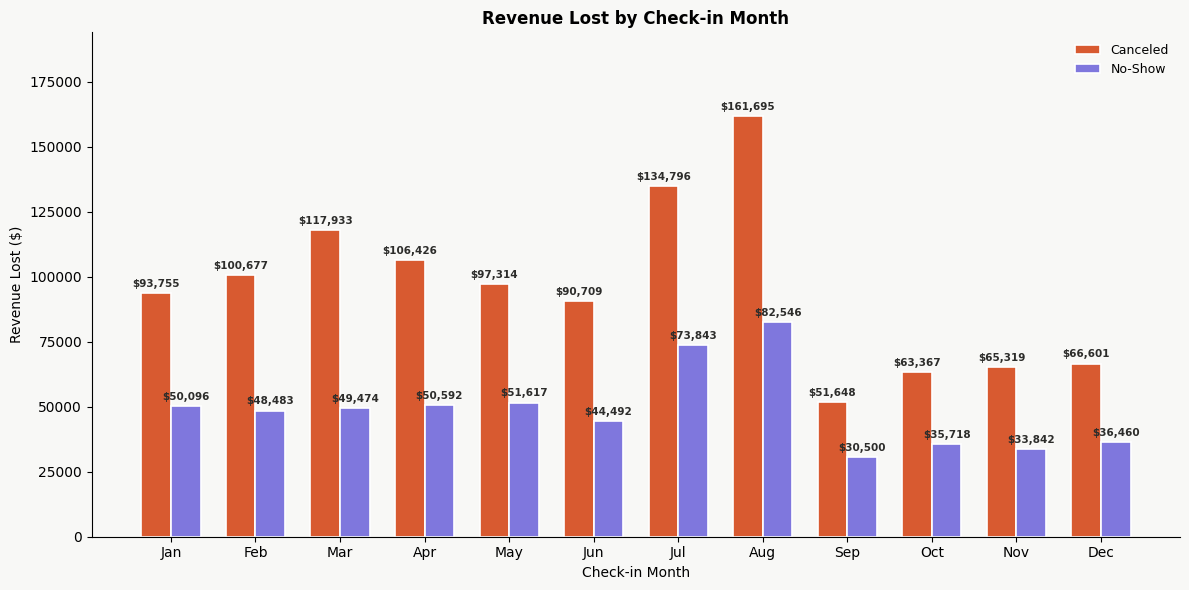

In [ ]:
# chart 7 - revenue lost by check-in month and reservation status
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)

monthly_lost_rev = (
    df_rev[df_rev['Reservation_Status'].isin(['Canceled', 'No-Show'])]
    .groupby(['checkin_month', 'checkin_month_name', 'Reservation_Status'])['revenue_lost']
    .sum()
    .unstack(fill_value=0)
)

monthly_lost_rev = monthly_lost_rev.reindex(columns=['Canceled', 'No-Show'], fill_value=0)

# SORTING
monthly_lost_rev = monthly_lost_rev.sort_index(
    level='checkin_month_name',
    key=lambda x: x.map(lambda m: MONTH_ORDER.index(m))
)

x = np.arange(len(monthly_lost_rev.index))
width = 0.35

bars_canceled = ax.bar(
    x - width/2,
    monthly_lost_rev['Canceled'],
    width=width,
    color=PALETTE['Canceled'],
    edgecolor='white',
    linewidth=1.2,
    label='Canceled'
)

bars_no_show = ax.bar(
    x + width/2,
    monthly_lost_rev['No-Show'],
    width=width,
    color=PALETTE['No-Show'],
    edgecolor='white',
    linewidth=1.2,
    label='No-Show'
)

# Labels
max_val = monthly_lost_rev.values.max()

for bars in [bars_canceled, bars_no_show]:
    for bar in bars:
        v = bar.get_height()
        if v > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                v + (max_val * 0.01),
                f'${v:,.0f}',
                ha='center', va='bottom', fontsize=7.5,
                fontweight='bold', color='#2C2C2A'
            )

ax.set_xticks(x)
ax.set_xticklabels(monthly_lost_rev.index.get_level_values('checkin_month_name'))
ax.set_title('Revenue Lost by Check-in Month', fontweight='bold', fontsize=12)
ax.set_xlabel('Check-in Month')
ax.set_ylabel('Revenue Lost ($)')
ax.set_ylim(0, max_val * 1.2)

ax.legend(frameon=False, fontsize=9)
ax.set_facecolor(BG)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()